## 실행1

In [65]:
# 라이브러리 기본 참조
from hossam import load_data
from hossam.util import hs_load_data
from pandas import DataFrame, melt
from matplotlib import pyplot as plt
from matplotlib import font_manager as fm
import seaborn as sb
import numpy as np
# 선형회귀를 위한 참조
import statsmodels.api as sm
from statsmodels.formula.api import ols
# 결과 검정을 위한 참조
from statsmodels.stats.diagnostic import linear_reset
from scipy.stats import zscore, probplot, shapiro, anderson
from statsmodels.stats.api import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
# VIF값을 계산하기 위한 참조
from statsmodels.stats.outliers_influence import variance_inflation_factor
import seaborn as sns

In [66]:
my_dpi = 200 # 이미지 선명도(100~300)
fpath = "./NotoSansKR-Regular.ttf" # 한글을 지원하는 폰트 파일의 경로
fm.fontManager.addfont(fpath) # 폰트의 글꼴을 시스템에 등록함
fprop = fm.FontProperties(fname=fpath) # 폰트의 속성을 읽어옴
fname = fprop.get_name() # 읽어온 속성에서 폰트 이름 추출
plt.rcParams['font.family'] = fname # 그래프에 한글 폰트 적용
plt.rcParams['font.size'] = 6 # 기본 폰트 크기
plt.rcParams['axes.unicode_minus'] = False # 그래프에 마이너스 깨짐 방지

In [67]:
origin = load_data("california_housing")

print("\n===== 데이터 크기 확인 =====")
print(f"데이터셋 크기: {origin.shape}")
print(f"열 개수: {origin.shape[1]}")
print(f"행 개수: {origin.shape[0]}")
print("\n===== 타입확인 =====")
print(origin.info())
origin.head()

[data] https://data.hossam.kr/kaggle/california_housing.xlsx
[desc] 1990년 미국 인구조사(Census)를 기반으로 캘리포니아 각 지역의 인구·주택·소득 특성과 주택 중위가격을 담아, 회귀 분석과 머신러닝 모델 실습에 널리 사용되는 대표적인 주택 가격 데이터 (출처: https://www.kaggle.com/datasets/camnugent/california-housing-prices)

field               description
------------------  ------------------------------------------------------------------------------
longitude           경도(Longitude). 서경(–값) 기준.
latitude            위도(Latitude). 북위(+) 기준.
housing_median_age  해당 구역(블록 그룹)의 주택 중위 연령(년).
total_rooms         구역 내 모든 주택의 총 방(room) 수 합계.
total_bedrooms      구역 내 모든 주택의 총 침실(bedroom) 수 합계.
population          구역의 전체 인구 수.
households          구역의 전체 “가구 수”(living units).
median_income       구역의 중위 소득(median income), 단위는 약 1 = $10,000 수준.
median_house_value  주택 중위가격(달러). 회귀의 목표변수(타깃).
ocean_proximity     해안과의 거리/접근성 범주: <1H OCEAN, INLAND, NEAR BAY, NEAR OCEAN, ISLAND 등.


===== 데이터 크기 확인 =====
데이터셋 크기: (20640, 10)
열 개수: 10
행 개수: 20640

===== 타입확인 =====
<class 'panda

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY


In [68]:
origin["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [69]:
hossam = hs_load_data("california_cluster.xlsx")

print("\n===== 데이터 크기 확인 =====")
print(f"데이터셋 크기: {hossam.shape}")
print(f"열 개수: {hossam.shape[1]}")
print(f"행 개수: {hossam.shape[0]}")
print("\n===== 타입확인 =====")
print(hossam.info())
hossam.head()


✅ 테이블 정보
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   longitude   20640 non-null  float64
 1   latitude    20640 non-null  float64
 2   housing_me  20640 non-null  int64  
 3   total_room  20640 non-null  int64  
 4   total_bedr  20433 non-null  float64
 5   population  20640 non-null  int64  
 6   households  20640 non-null  int64  
 7   median_inc  20640 non-null  float64
 8   median_hou  20640 non-null  int64  
 9   ocean_prox  20640 non-null  object 
 10  CLUSTER_ID  20640 non-null  int64  
dtypes: float64(4), int64(6), object(1)
memory usage: 1.7+ MB


✅ 상위 5개 행
+---+-----------+----------+------------+------------+------------+------------+------------+-------------------+------------+------------+------------+
|   | longitude | latitude | housing_me | total_room | total_bedr | population | households |    median_inc     | median_

,longitude,latitude,housing_me,total_room,total_bedr,population,households,median_inc,median_hou,ocean_prox,CLUSTER_ID
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY,5
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY,5
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY,5
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY,5
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY,5


미션1_“이 데이터는 믿을 만할까?”
결측·이상치·편향을 점검하고, 처리 기준을 제시한다.<br>
MedHouseValue가 0이거나 극단값인지, MedInc/HouseAge/AveRooms 등 주요 변수의 범위가 현실적인지 확
인한다.<br>
1940년 이전 건축 주택이 52로 코딩되는 이유를 이해하고, 분석에 미칠 영향을 검토한다.<br>
전처리 전·후가 어떻게 달라졌는지 한눈에 비교하는 표나 요약을 만든다.<br>
단위·해석 주의: MedHouseValue는 실제 달러 단위입니다. 1990년 명목가를 참고해 현실성을 평가하세요.<br>
📌 출제 의도 “이 값이 말이 되나?”를 먼저 묻고, 어떻게 처리했는지를 기록해 나중 해석에 근거를 남기는 연습입니
다

In [70]:
# median_house_value 를 예측하기 위해 median_income, housing_median_age, ave_rooms의 사분위수 분포 구함
col_desc = {
    'longitude': '경도(Longitude). 서경(-값) 기준.',
    'latitude': '위도(Latitude). 북위(+) 기준.',
    'housing_median_age': '해당 구역(블록 그룹)의 주택 중위 연령(년).',
    'total_rooms': '구역 내 모든 주택의 총 방(room) 수 합계.',
    'total_bedrooms': '구역 내 모든 주택의 총 침실(bedroom) 수 합계.',
    'population': '구역의 전체 인구 수.',
    'households': '구역의 전체 가구 수(living units).',
    'median_income': '구역의 중위 소득(median income), 단위는 약 1 = $10,000.',
    'median_house_value': '주택 중위가격(달러). 회귀의 목표변수(타깃).',
    'ocean_proximity': '해안과의 거리/접근성 범주.'
}

df = origin.copy()

df["ave_rooms"] = df["total_rooms"] / df["households"]



for col, desc in col_desc.items():
    print(f'[{col}]')
    print(desc)
    print('-' * 60)

vars_of_interest = [
    "median_house_value",
    "median_income",
    "housing_median_age",
    "ave_rooms",
    
]


print(f"52라는 수치가 존재하는 이유는, 상한 포화 문제 때문에 그렇다.\n")
df[vars_of_interest].describe(percentiles=[0.25, 0.5, 0.75])


[longitude]
경도(Longitude). 서경(-값) 기준.
------------------------------------------------------------
[latitude]
위도(Latitude). 북위(+) 기준.
------------------------------------------------------------
[housing_median_age]
해당 구역(블록 그룹)의 주택 중위 연령(년).
------------------------------------------------------------
[total_rooms]
구역 내 모든 주택의 총 방(room) 수 합계.
------------------------------------------------------------
[total_bedrooms]
구역 내 모든 주택의 총 침실(bedroom) 수 합계.
------------------------------------------------------------
[population]
구역의 전체 인구 수.
------------------------------------------------------------
[households]
구역의 전체 가구 수(living units).
------------------------------------------------------------
[median_income]
구역의 중위 소득(median income), 단위는 약 1 = $10,000.
------------------------------------------------------------
[median_house_value]
주택 중위가격(달러). 회귀의 목표변수(타깃).
------------------------------------------------------------
[ocean_proximity]
해안과의 거리/접근성 범주.
------------------------------

,median_house_value,median_income,housing_median_age,ave_rooms
count,20640.000000,20640.000000,20640.000000,20640.000000
mean,206855.816909,3.870671,28.639486,5.429000
std,115395.615874,1.899822,12.585558,2.474173
min,14999.000000,0.499900,1.000000,0.846154
25%,119600.000000,2.563400,18.000000,4.440716
50%,179700.000000,3.534800,29.000000,5.229129
75%,264725.000000,4.743250,37.000000,6.052381
max,500001.000000,15.000100,52.000000,141.909091


In [71]:
(df["median_house_value"]==500001).mean()

np.float64(0.04675387596899225)

In [72]:
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

전처리 전/후 비교용 요약표

In [73]:
import pandas as pd
summary_before = df[vars_of_interest].quantile([0.25, 0.5, 0.75])

# 예: avg_rooms 이상치 컷
df_clean = df[df["ave_rooms"] < 10]

summary_after = df_clean[vars_of_interest].quantile([0.25, 0.5, 0.75])

pd.concat(
    {"before": summary_before, "after": summary_after},
    axis=1
)


before                                             \
     median_house_value median_income housing_median_age ave_rooms   
0.25           119600.0       2.56340               18.0  4.440716   
0.50           179700.0       3.53480               29.0  5.229129   
0.75           264725.0       4.74325               37.0  6.052381   

                  after                                             
     median_house_value median_income housing_median_age ave_rooms  
0.25           119800.0        2.5625               18.0  4.432065  
0.50           180400.0        3.5341               29.0  5.213198  
0.75           265200.0        4.7426               37.0  6.016000

In [74]:
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
ave_rooms               0
dtype: int64

In [75]:
df.dropna(axis=1)

,longitude,latitude,housing_median_age,total_rooms,population,households,median_income,median_house_value,ocean_proximity,ave_rooms
0,-122.23,37.88,41,880,322,126,8.3252,452600,NEAR BAY,6.984127
1,-122.22,37.86,21,7099,2401,1138,8.3014,358500,NEAR BAY,6.238137
2,-122.24,37.85,52,1467,496,177,7.2574,352100,NEAR BAY,8.288136
3,-122.25,37.85,52,1274,558,219,5.6431,341300,NEAR BAY,5.817352
4,-122.25,37.85,52,1627,565,259,3.8462,342200,NEAR BAY,6.281853
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25,1665,845,330,1.5603,78100,INLAND,5.045455
20636,-121.21,39.49,18,697,356,114,2.5568,77100,INLAND,6.114035
20637,-121.22,39.43,17,2254,1007,433,1.7000,92300,INLAND,5.205543
20638,-121.32,39.43,18,1860,741,349,1.8672,84700,INLAND,5.329513


📝 미션 2. “가격과 핵심 변수의 첫인상”<br>
MedHouseValue, MedInc, HouseAge, AveRooms 분포를 히스토그램/KDE로 확인하고 알 수 있는 객관적 사
실을 서술한다.<br>
왜도/이상치가 회귀에 줄 수 있는 영향과 변환할 필요가 있는지 서술하시오.<br>
분포 비교는 동일 축 스케일로 제시하고, 평균/중앙값/꼬리의 차이를 문장으로 요약하세요.<br>
지역별(Latitude/Longitude) 편향이나 시계열 문제(1990년 데이터만)가 해석에 미치는 영향도 짧게 언급하세요.<br>
📌 출제 의도 목표변수·핵심 변수의 생김새를 먼저 읽고 변환 필요성을 스스로 판단하게 합니다. 숫자보다 해석 문
장이 중요합니다

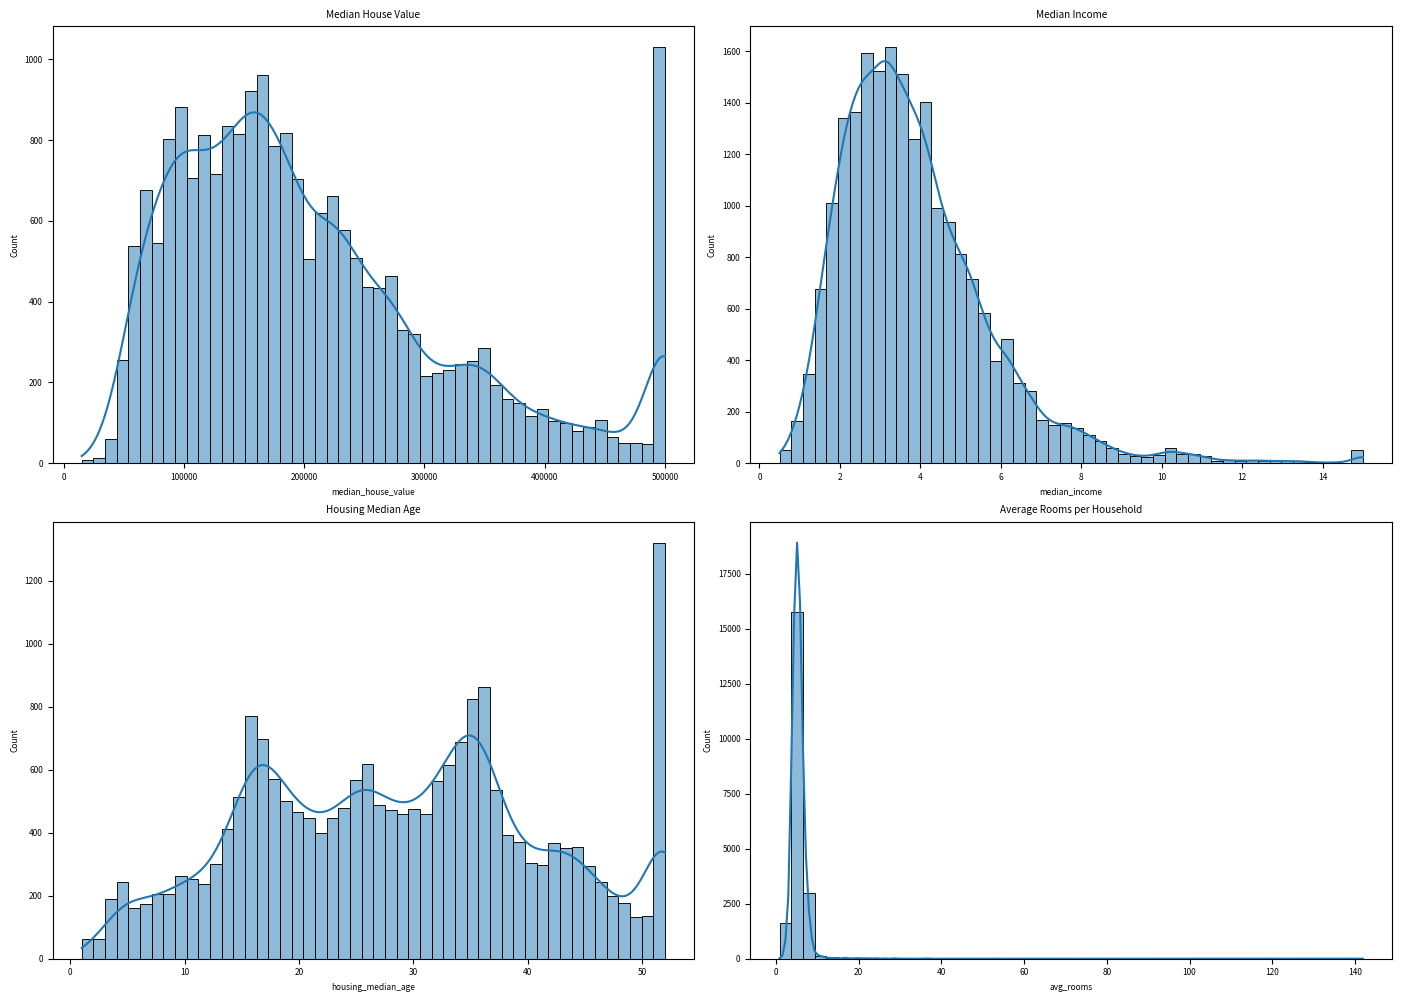

=====Median House Value=====
강한 우측 꼬리
평균은 상단 값에 끌려 왜곡
선형 회귀에서:잔차 비정상성,고가 예측 한계 발생 가능

=====Medianincom=====
우측으로 긴 꼬리
저소득 구간에 밀집, 고소득은 희소
전형적인 경제 변수 분포

=====Housing Median Age=====
1~52까지 비교적 고르게 분포
52에서 강한 수직 스파이크
52는 52년 된 집이 아니라 1940년 이전 건축을 하나로 묶은 코드
연속형 변수처럼 보이지만 사실상:
연속+범주가 섞인 혼합 변수
평균/분산 해석이 왜곡됨

=====AVG Rooms=====
중심은 3~6
우측 꼬리가 김
극단값(10~20+)존재
왜?
households가 매우 작은 지역
total_rooms는 큰 경우 발생
수학적 비율 변수의 전형적 이상치


In [76]:
import seaborn as sb
import matplotlib.pyplot as plt
my_dpi = 100
rows, cols = 2, 2

fig, axes = plt.subplots(
    rows, cols,
    figsize=(14, 10),
    dpi=my_dpi
)

df["avg_rooms"] = df["total_rooms"] / df["households"]

axes = axes.flatten()

vars_info = [
    ("median_house_value", "Median House Value"),
    ("median_income", "Median Income"),
    ("housing_median_age", "Housing Median Age"),
    ("avg_rooms", "Average Rooms per Household")
]

for ax, (col, title) in zip(axes, vars_info):
    sb.histplot(
        data=df,
        x=col,
        bins=50,
        kde=True,
        ax=ax,
        
    )
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()
print(f"=====Median House Value=====\n강한 우측 꼬리\n평균은 상단 값에 끌려 왜곡\n선형 회귀에서:잔차 비정상성,고가 예측 한계 발생 가능\n\n=====Medianincom=====\n우측으로 긴 꼬리\n저소득 구간에 밀집, 고소득은 희소\n전형적인 경제 변수 분포\n\n=====Housing Median Age=====\n1~52까지 비교적 고르게 분포\n52에서 강한 수직 스파이크\n52는 52년 된 집이 아니라 1940년 이전 건축을 하나로 묶은 코드\n연속형 변수처럼 보이지만 사실상:\n연속+범주가 섞인 혼합 변수\n평균/분산 해석이 왜곡됨"
      f"\n\n=====AVG Rooms=====\n중심은 3~6\n우측 꼬리가 김\n극단값(10~20+)존재\n왜?\nhouseholds가 매우 작은 지역\ntotal_rooms는 큰 경우 발생\n수학적 비율 변수의 전형적 이상치")

-----시계열-----<br>
📌Latitude/Longitude<br>
캘리포니아는<br>
해안 vs 내륙<br>
북부 vs 남부<br>
분포 왜곡의 상당 부분은 공간적 요인<br><br>

📌시계열 문제<br>
데이터 기준:1990년 Census<br>
현재 가격 수준과 직접 비교 불가<br>
해석은 반드시:<br>
"19190년 당시 상대적 가격" 기준

-----결론-----<br>
본 데이터의 핵심 변수들은 대부분<br>
비대칭 분포, 상한 처리, 이상치를 포함하고 있어<br>
단순 평균 기반 해석이나<br>
변환 없는 회귀 분석에 적합하지 않다.<br>
따라서 목표 변수와 설명 변수의 분포 특성을 먼저 이해하고,<br>
로그변환, 구간화, 더미 분리 등의 전처리를 통해<br>
모델 해석 가능성을 확보하는 것이 필수적

📝 미션 3. “로그/비선형 변환을 고민해 보자”<br>
MedHouseValue 혹은 주요 변수(MedInc, Population,HouseAge)<br>에 로그/제곱근 등 변환을 적용해 전후 분포
를 나란히 비교한다.<br>
변환이 해석과 모델 적합에 주는 장단점, 해석이 어떻게 달라지는지 예상한다.<br>
“이 변환이 없으면 어떤 함정에 빠질까?”를 한 줄로 정리한다.<br>
선택 기준을 명시하세요: 왜 log(MedHouseValue)인지,<br>
왜 Population에 로그인지 등 데이터 분포 근거로 설명합니다.<br>
필요한 경우 Box-Cox 등의 변환을 비교해 가장 해석 친화적인 옵션을 선택하세요.<br>
📌 출제 의도 단순히 변환을 쓰는 것이 아니라 “왜 필요했는가, 해석이 어떻게 달라지는가”를 설명하는 연습입니다.<br>

1. 핵심 가설 설정 (분석 전에 반드시 필요)<br>
가설 A (구조적 가설)<br>

오래된 주택일수록<br>

가구 수 대비 방 수가 작거나<br>

침실 비율이 다르거나<br>

주거 밀도가 다르다<br>

즉, housing_median_age는 단독 변수라기보다<br>
주거 구조 변수들과 “결합될 때” 의미를 갖는다는 가설입니다.

In [77]:
# 파생 변수 생성
df = origin.copy()

df["avg_rooms"] = df["total_rooms"] / df["households"]
df["avg_bedrooms"] = df["total_bedrooms"] / df["households"]
df["bedroom_ratio"] = df["total_bedrooms"] / df["total_rooms"]

# housing_median_age를 "연속값"이 아니라 "구간"으로 본다
df["age_bin"] = pd.qcut(
    df["housing_median_age"],
    q=4,
    labels=["Q1(young)", "Q2", "Q3", "Q4(old)"]
)
print(f"Q4가 반드시 52만 있는지\nQ1~Q3 내부 분산이 구조 변수로 설명되는지")

Q4가 반드시 52만 있는지
Q1~Q3 내부 분산이 구조 변수로 설명되는지


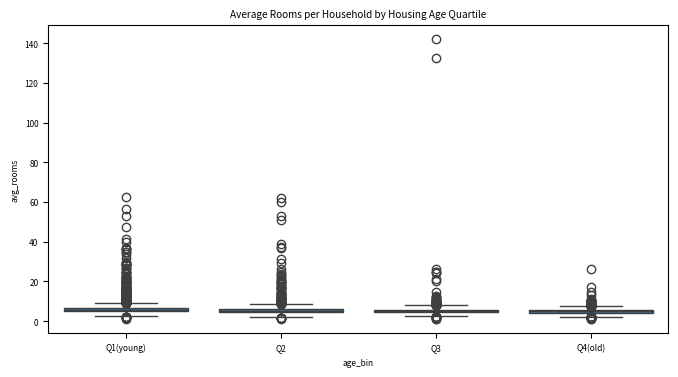

In [78]:
# age_bin vs avg_rooms
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
sns.boxplot(x="age_bin", y="avg_rooms", data=df)
plt.title("Average Rooms per Household by Housing Age Quartile")
plt.show()


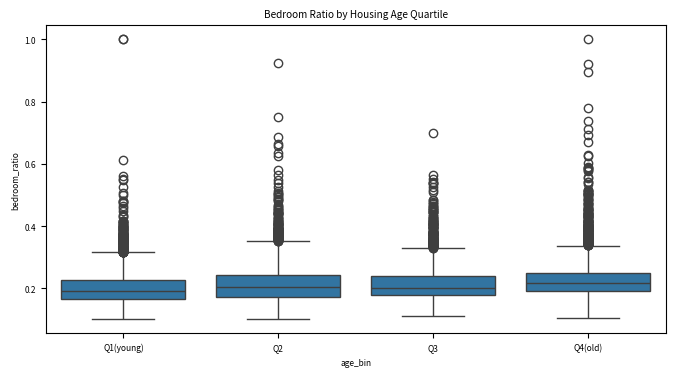

침실수는 선형성이 없는건가?


In [79]:
# age_bin vs bedroom_ratio
plt.figure(figsize=(8, 4))
sns.boxplot(x="age_bin", y="bedroom_ratio", data=df)
plt.title("Bedroom Ratio by Housing Age Quartile")
plt.show()
print(f"침실수는 선형성이 없는건가?")

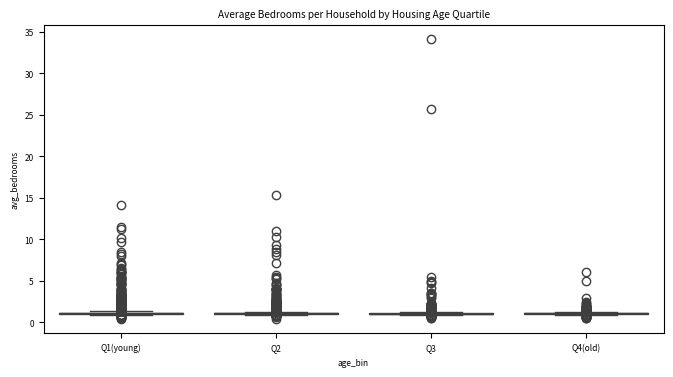

In [80]:
# age_bin vs avg_bedrooms
plt.figure(figsize=(8, 4))
sns.boxplot(x="age_bin", y="avg_bedrooms", data=df)
plt.title("Average Bedrooms per Household by Housing Age Quartile")
plt.show()


경우 ①<br>

age가 증가할수록 avg_rooms가 감소<br>

오래된 지역 = 소형 주택 위주<br>

age 분산은 실제 도시 구조 차이<br>

→ housing_median_age는 의미 있는 설명 변수<br><br>

경우 ②<br>

age와 구조 변수 간 차이가 거의 없음<br>
분산은 행정 단위/코딩 단위 노이즈<br>

→ housing_median_age 단독 사용 위험<br>

→ 다른 변수와의 interaction 필요<br><br>


경우 ③<br>

Q4(52)에서만 구조가 급격히 달라짐<br>

“1940년 이전”이라는 역사적 단층<br>

→ age_is_capped 이진 변수 도입 타당

In [81]:
# 정량적 검증(상관 + 분산 설명)
df[[
    "housing_median_age",
    "avg_rooms",
    "avg_bedrooms",
    "bedroom_ratio"
]].corr()


,housing_median_age,avg_rooms,avg_bedrooms,bedroom_ratio
housing_median_age,1.000000,-0.153277,-0.077918,0.136089
avg_rooms,-0.153277,1.000000,0.848616,-0.416952
avg_bedrooms,-0.077918,0.848616,1.000000,0.055905
bedroom_ratio,0.136089,-0.416952,0.055905,1.000000


구조 변수 × 가격의 interaction term

In [82]:
# 구조 변수 생성
df = origin.copy()

df["avg_rooms"] = df["total_rooms"] / df["households"]
df["avg_bedrooms"] = df["total_bedrooms"] / df["households"]
df["bedroom_ratio"] = df["total_bedrooms"] / df["total_rooms"]


In [83]:
# age 상한을 분리
df["age_is_capped"] = (df["housing_median_age"] == 52).astype(int)


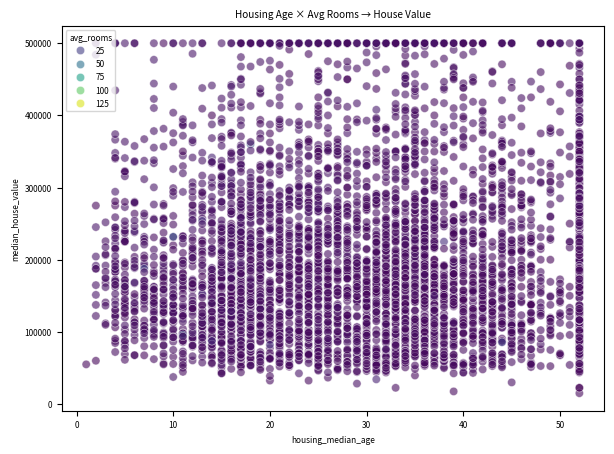

-----중요-----
housing_median_age와 avg_rooms는 주택 가격에 대해 직접적,단독적 선형 관계를 가지는 않지만,
다른 핵심 변수(특히 소득,지역)와 결합될 때
가격 분산의 구조를 설명하는 조건부 변수로 작용


구간별로 값의 분포 나열 가능


In [84]:
# 1차 시각 분석: 구조 × 가격
# housing_median_age × avg_rooms → 가격
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df.sample(5000, random_state=42),
    x="housing_median_age",
    y="median_house_value",
    hue="avg_rooms",
    palette="viridis",
    alpha=0.6
)
plt.title("Housing Age × Avg Rooms → House Value")
plt.show()
print(f"-----중요-----\nhousing_median_age와 avg_rooms는 주택 가격에 대해 직접적,단독적 선형 관계를 가지는 않지만,\n다른 핵심 변수(특히 소득,지역)와 결합될 때\n가격 분산의 구조를 설명하는 조건부 변수로 작용")

print(f"\n\n구간별로 값의 분포 나열 가능")


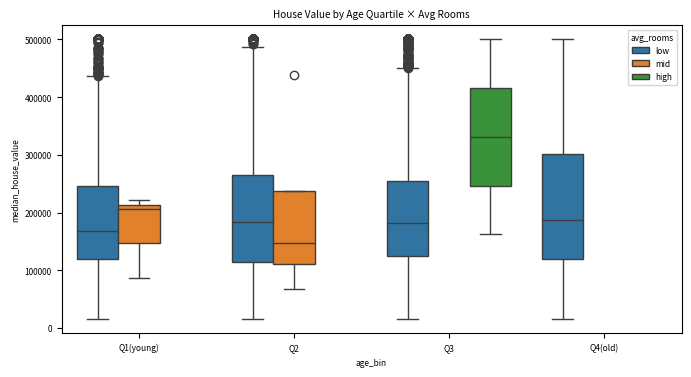

In [85]:
# age 구간별 avg_rooms × 가격
df["age_bin"] = pd.qcut(
    df["housing_median_age"],
    q=4,
    labels=["Q1(young)", "Q2", "Q3", "Q4(old)"]
)

plt.figure(figsize=(8, 4))
sns.boxplot(
    x="age_bin",
    y="median_house_value",
    hue=pd.cut(df["avg_rooms"], bins=3, labels=["low", "mid", "high"]),
    data=df
)
plt.title("House Value by Age Quartile × Avg Rooms")
plt.show()


예상대로 방 수가 많은 주택의 주택 중위 가격이 높았음.<br>
또한, 최신형 주택일 때 방 수가 적은 박스플롯이 방 수가 적은 low가<br>
mid보다 사분위수 구간이 더 낮은 쪽에 위치함에도 불구하고 mid와 달리 이상치가 발견된 것에 의문<br>


In [124]:
# median_income 사분위 구간 생성
df = origin.copy()

# Low income, Mid-low, Mid-high, High income으로 나눔
df["income_bin"] = pd.qcut(
    df["median_income"],
    q=4,
    labels=["Low income", "Mid-Low", "Mid-High", "High income"]
)



C:\Users\itwill\AppData\Local\Temp\ipykernel_21724\115538815.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\itwill\AppData\Local\Temp\ipykernel_21724\115538815.py:9: UserWarning: The palette list has more values (9) than needed (4), which may not be intended.
  sns.boxplot(


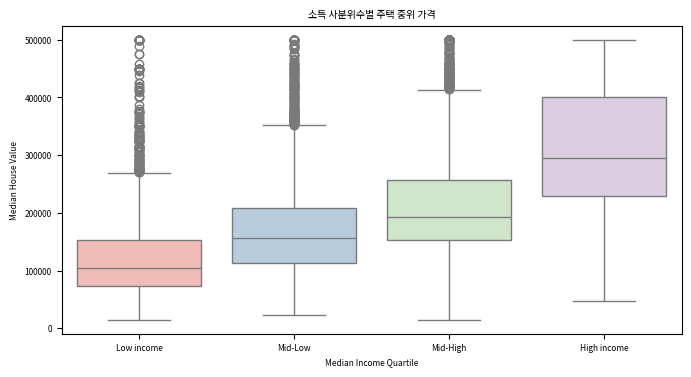

Low income에서 더 높은  소득들 보다 높은 값으로 이상치가 발견되는데
이러한 현상은 어떠한 변수로 인해 영향을 받는가?
 👉일부 고가 주택
 👉일부 고자산 가구
 👉투자 목적 보유 주택
📌 즉
소득은 “누가 많냐”를 말해주지
“누가 가장 비싼 집을 샀냐”를 말해주지 않는다.
2️⃣ 2차 원인 (가장 중요): 입지(Location) 변수의 지배력
Low income에서 나타나는 고가 이상치의 가장 강력한 원인
작동 메커니즘
해안 인접 (NEAR OCEAN, NEAR BAY)
도심 핵심 지역
개발 제한 구역
이런 곳은:
주민 소득이 낮아도
토지 희소성 + 입지 프리미엄으로 가격이 높다.

3️⃣ 3차 원인: median_house_value 상한 포화 효과
median_house_value 상한 = 500,001
High income 구간:고가 주택이 상한에 걸려 눌림
Low income 구간:일부 고가 주택이 상대적으로 더 튀어 보임
📌 결과적으로:
High income의 **진짜 고가**는 보이지 않고, Low income의 **예외적 고가**만 눈에 띈다.
4️⃣ 4차 원인: 주택 구조 변수의 영향 (방 수·밀도)
avg_rooms가 매우 크거나
ave_occup가 매우 낮은 지역
👉 대형 단독주택 + 인구 적음
소득 수준과 무관하게 주택 가격은 높아질 수 있음
📌 특히:
👉은퇴 지역
👉세컨드 하우스 지역
👉임대/투자 목적 지역


그렇다면 어떤 변수가 이러한 현상에 가장 많은 영향을 미칠까?
(가장 많이 영향을 미치는 순)
ocean_proximity > location(위도·경도) > 주택 구조 변수(avg_rooms, density)
왜 회귀에서 이 변수를 빼면 이상치가 생기나?
ocean_proximity를 포함하지 않으면:해안 프리미엄이 설명되지 않음그 결과, 고가 주택이 잔차(outlier) 로 튀어나옴


In [125]:
df["income_bin"] = pd.qcut(
    df["median_income"],
    q=4,
    labels=["Low income", "Mid-Low", "Mid-High", "High income"]
)

palette = sns.color_palette('Pastel1')
plt.figure(figsize=(8, 4))
sns.boxplot(
    x="income_bin",
    y="median_house_value",
    data=df,
    palette = palette
)

plt.title("소득 사분위수별 주택 중위 가격")
plt.xlabel("Median Income Quartile")
plt.ylabel("Median House Value")
plt.show()
print(f"Low income에서 더 높은  소득들 보다 높은 값으로 이상치가 발견되는데\n이러한 현상은 어떠한 변수로 인해 영향을 받는가?\n 👉일부 고가 주택\n 👉일부 고자산 가구\n 👉투자 목적 보유 주택\n📌 즉\n소득은 “누가 많냐”를 말해주지\n“누가 가장 비싼 집을 샀냐”를 말해주지 않는다.")
print(f"2️⃣ 2차 원인 (가장 중요): 입지(Location) 변수의 지배력\nLow income에서 나타나는 고가 이상치의 가장 강력한 원인\n작동 메커니즘\n해안 인접 (NEAR OCEAN, NEAR BAY)\n도심 핵심 지역\n개발 제한 구역\n이런 곳은:\n주민 소득이 낮아도\n토지 희소성 + 입지 프리미엄으로 가격이 높다.\n")
print(f"3️⃣ 3차 원인: median_house_value 상한 포화 효과\nmedian_house_value 상한 = 500,001\nHigh income 구간:고가 주택이 상한에 걸려 눌림\nLow income 구간:일부 고가 주택이 상대적으로 더 튀어 보임\n📌 결과적으로:\nHigh income의 **진짜 고가**는 보이지 않고, Low income의 **예외적 고가**만 눈에 띈다.")
print(f"4️⃣ 4차 원인: 주택 구조 변수의 영향 (방 수·밀도)\navg_rooms가 매우 크거나\nave_occup가 매우 낮은 지역\n👉 대형 단독주택 + 인구 적음\n소득 수준과 무관하게 주택 가격은 높아질 수 있음\n📌 특히:\n👉은퇴 지역\n👉세컨드 하우스 지역\n👉임대/투자 목적 지역")
print(f"\n\n그렇다면 어떤 변수가 이러한 현상에 가장 많은 영향을 미칠까?\n(가장 많이 영향을 미치는 순)\nocean_proximity > location(위도·경도) > 주택 구조 변수(avg_rooms, density)")
print(f"왜 회귀에서 이 변수를 빼면 이상치가 생기나?\nocean_proximity를 포함하지 않으면:해안 프리미엄이 설명되지 않음그 결과, 고가 주택이 잔차(outlier) 로 튀어나옴")

1순위 변수: 해안 접근성<br>
소득보다 집값에 더 직접적으로 작용<br>
저소득 주민이 많이 사는 지역이라도 해안에 붙어있으면 가격은 높아진다.<br>
그렇다면 Low income일수록 해안에 거주하는 사람들이 많은가?<br><br>

2순위 변수: 위치 좌표 (latitude, longitude)<br>
왜 소득보다 강한가?<br>
👉Low income 고가 이상치의 전형적 위치<br>
👉샌프란시스코 인근<br>
👉LA 해안 인접<br>
👉베이 에어리어 외곽<br>
이 지역의 특징:<br>
평균 소득은 낮아도 토지 가격 자체가 비쌈<br>
📌 그래서:<br>
위치 변수를 통제하지 않으면<br>
소득의 효과가 과대평가되고,<br>
위치 프리미엄이 “이상치”로 나타난다.<br><br>

3️⃣ 3순위 변수: 주택 구조 변수 (avg_rooms, density)<br>
→ 은퇴 지역, 세컨드 하우스, 투자용 주택

소득은 낮은데 집값은 비정상적으로 높고, 공급이 제한된 위치<br>
→ 거의 항상 개발 제약이 있는 지역



"개발제한 시그널” 조합

① ocean_proximity + 고가 이상치

In [126]:
df["ocean_proximity"].value_counts()


ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

👉 개발제한의 간접 증거

In [127]:
df.groupby("ocean_proximity")[["median_income", "median_house_value"]].mean()
print(f"near bay -> 로스엔젤러스와 같이 내륙지역인데도 불구하고 해안 근처에 있는 지역들이 최고가 주택이 있는 500001 지역의 주택이 형성된 지역보다 가격이 조금 더 높은 이유는, ")


near bay -> 로스엔젤러스와 같이 내륙지역인데도 불구하고 해안 근처에 있는 지역들이 최고가 주택이 있는 500001 지역의 주택이 형성된 지역보다 가격이 조금 더 높은 이유는, 


NEAR BAY의 “평균 집값”이 NEAR OCEAN보다 높은 이유는<br>
최고가(outlier) 때문이 아니라, ‘고가 주택이 얼마나 많이·지속적으로 존재하느냐’의 차이인 것 같다.<br>

<br><br>

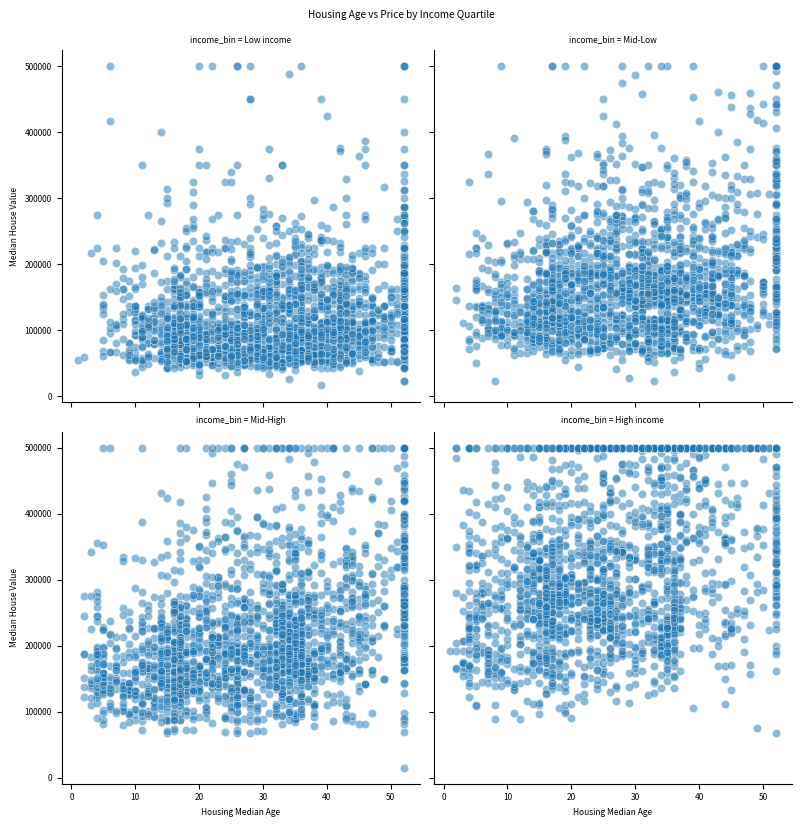

-----가격의 분산 구조-----
같은 소득 수준에서, 주택 연령이 가격 분포에 어떤 역할을 하는가소득이 통제된 상태에서의 조건부 현상

income_bin이 Mid_High인 패널에에서는 소득자체가 고가 형성을 허용함.
즉, 가격 상한이 열린 상태
오래된 집 중에서도 입지 좋고 역사적 주거지인 곳들이 고가로 남아있음
고소득 지역에서는 오래된 집도 비쌀 수 있다
역사적인 주거지 -> 

Low income일 경우
가격 상단이 약 200k 전후에서 제한
age증가에도 상단이 거의 안 움직임
분산도 비교적 작음
-->소득이 낮으면 오래된 집이여도 고가 형성 불가
Mid-Low income일 경우
가격 상단이 약 300k까지 확장
age 증가와 함께 분산이 약간 커짐
age가 단독 요인으로 작동하기 시작
하지만 여전히 소득이 가격을 지배

Mid-High income일 경우
상단이 400~500k까지 열림
age 20~40구간에서 고가 밀집
주택 연령이 노후가 아니라 성숙한 주거지를 의미하는 구간 존재
age효과가 비선형적

High income
전 연령대에서 고가 존재
52(상한)에서 고가가 집중
분산이 매우 큼


In [128]:
# 소득 구간별로 age x price 산점도
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.FacetGrid(
    df.sample(8000, random_state=42),
    col="income_bin",
    col_wrap=2,
    height=4,
    sharex=True,
    sharey=True
)

g.map_dataframe(
    sns.scatterplot,
    x="housing_median_age",
    y="median_house_value",
    alpha=0.5
)

g.set_axis_labels("Housing Median Age", "Median House Value")
g.fig.suptitle("Housing Age vs Price by Income Quartile", y=1.02)

plt.show()
print(f"-----가격의 분산 구조-----\n같은 소득 수준에서, 주택 연령이 가격 분포에 어떤 역할을 하는가"
      f"소득이 통제된 상태에서의 조건부 현상\n\nincome_bin이 Mid_High인 패널에에서는 소득자체가 고가 형성을 허용함.\n즉, 가격 상한이 열린 상태\n오래된 집 중에서도 입지 좋고 역사적 주거지인 곳들이 고가로 남아있음\n고소득 지역에서는 오래된 집도 비쌀 수 있다"
      f"\n역사적인 주거지 -> "
      f"\n\nLow income일 경우\n가격 상단이 약 200k 전후에서 제한\nage증가에도 상단이 거의 안 움직임\n분산도 비교적 작음\n-->소득이 낮으면 오래된 집이여도 고가 형성 불가"
      f"\nMid-Low income일 경우\n가격 상단이 약 300k까지 확장\nage 증가와 함께 분산이 약간 커짐\nage가 단독 요인으로 작동하기 시작\n하지만 여전히 소득이 가격을 지배"
      f"\n\nMid-High income일 경우\n상단이 400~500k까지 열림\nage 20~40구간에서 고가 밀집\n주택 연령이 노후가 아니라 성숙한 주거지를 의미하는 구간 존재\nage효과가 비선형적"
      f"\n\nHigh income\n전 연령대에서 고가 존재\n52(상한)에서 고가가 집중\n분산이 매우 큼")

📝미션 3. “로그/비선형 변환을 고민해 보자”<br>
MedHouseValue 혹은 주요 변수(MedInc, Population, HouseAge)에 로그/제곱근 등 변환을 적용해 전후 분포를 나란히 비교한다.<br>
변환이 해석과 모델 적합에 주는 장단점, 해석이 어떻게 달라지는지 예상한다.“이 변환이 없으면 어떤 함정에 빠질까?”를 한 줄로 정리한다.<br>
선택 기준을 명시하세요: 왜 log(MedHouseValue)인지, 왜 Population에 로그인지 등 데이터 분포 근거로 설명합니다<br>

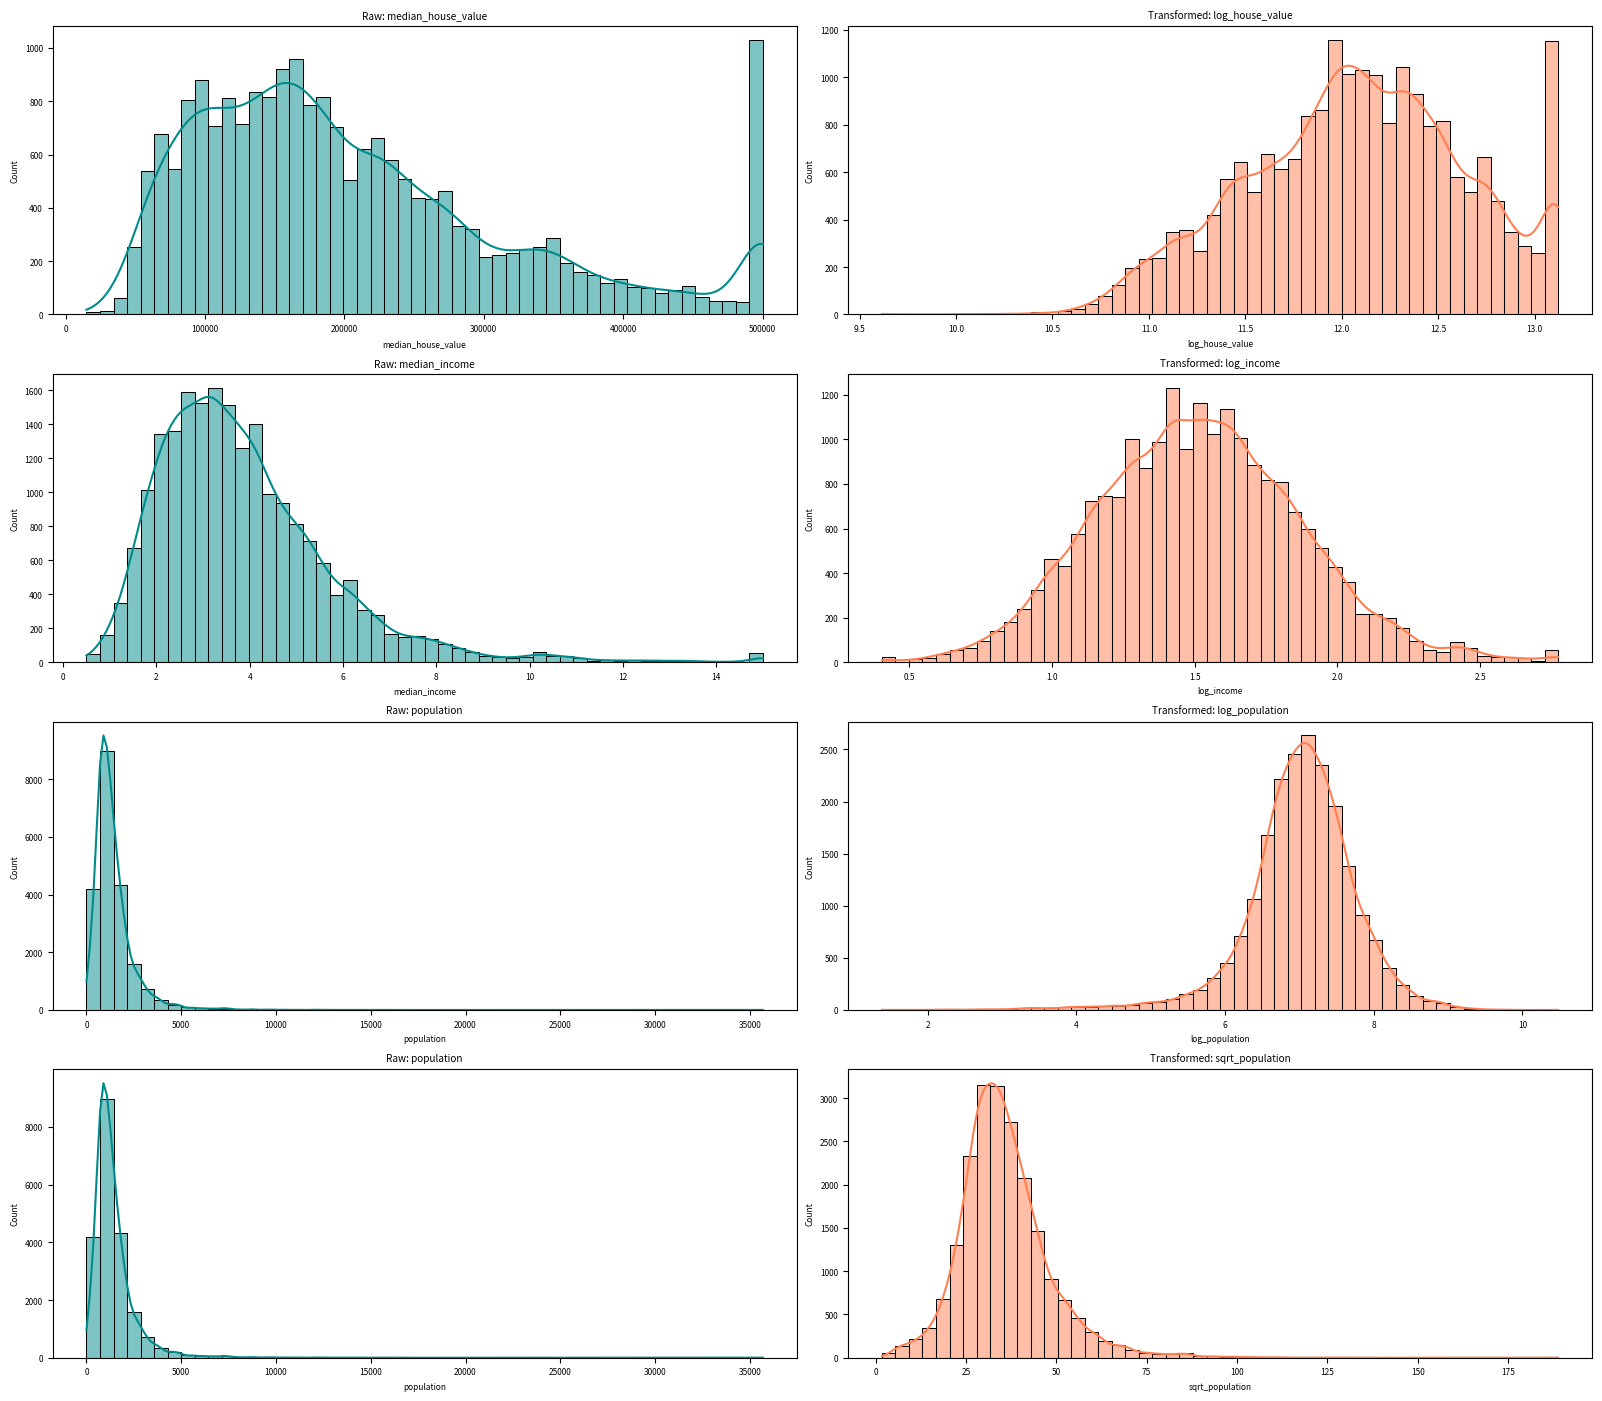

In [129]:

df = origin.copy()

# 파생 변수
df["avg_rooms"] = df["total_rooms"] / df["households"]

# 1️⃣ 변환 대상 변수 선택 (미션 명시)
# 목표변수: median_house_value
# 설명변수: median_income, population, housing_median_age


# 로그 / 제곱근 변환 적용
# (1) 로그 변환 (log1p: 0 대비 안전)
df["log_house_value"] = np.log1p(df["median_house_value"])
df["log_income"] = np.log1p(df["median_income"])
df["log_population"] = np.log1p(df["population"])

# (2) 제곱근 변환 (비교용)
df["sqrt_population"] = np.sqrt(df["population"])

# 변환 전/후 분포 비교 (나란히)
compare_pairs = [
    ("median_house_value", "log_house_value"),
    ("median_income", "log_income"),
    ("population", "log_population"),
    ("population", "sqrt_population")
]

fig, axes = plt.subplots(4, 2, figsize=(16, 14))

for i, (raw, trans) in enumerate(compare_pairs):

    sns.histplot(df[raw], bins=50, kde=True, ax=axes[i, 0], color = 'darkcyan')
    axes[i, 0].set_title(f"Raw: {raw}")

    sns.histplot(df[trans], bins=50, kde=True, ax=axes[i, 1], color = 'coral')
    axes[i, 1].set_title(f"Transformed: {trans}")

plt.tight_layout()
plt.show()


로그 변환 후, median_income이 정규성 분포를 띔<br>

<br>📌 선택 기준<br>
- median_house_value: 우측 편향 + 상한 포화 → log 필수<br>
- median_income: 경제 변수 특성상 비대칭 → log 권장<br>
- population: 규모 변수 → log 필수<br>
- housing_median_age: 절단 분포 → 로그보다 구간화/더미가 적절


📝미션 4. “지리적 위치는 정말 중요할까?”위도(Latitude)와 경도(Longitude)를 활용한 지리적 시각화를 수행한다.<br>
산점도(경도 × 위도, 점의 색상 = MedHouseValue)를 그려 주택 가격의 지리적 불평등을 관찰한다.<br>
“어느 지역이 비싼가?”, “가격 차이가 얼마나 뚜렷한가?”를 데이터 기반으로 설명하세요.<br>
위도/경도가 개별 변수보다 지역 표상(Proxy)이라는 점을 인식하고,<br> 이것이 회귀에 주는 의미를 논의하세요.

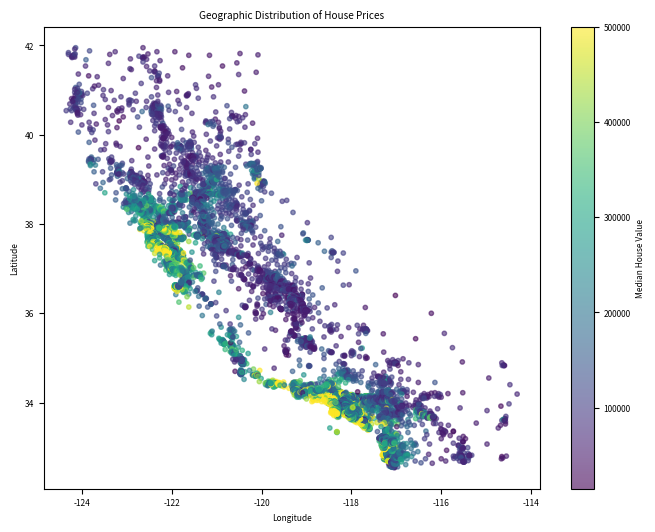

In [130]:
# 위도·경도 기반 가격 분포 시각화
plt.figure(figsize=(8, 6))

plt.scatter(
    df["longitude"],
    df["latitude"],
    c=df["median_house_value"],
    cmap="viridis",
    s=10,
    alpha=0.6
)

plt.colorbar(label="Median House Value")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographic Distribution of House Prices")
plt.show()


kmeans clustering

In [131]:
import pandas as pd
import numpy as np

cluster_features = [
    "median_house_value",
    "median_income",
    "housing_median_age",
    "population",
    "latitude",
    "longitude"
]


df_cluster = df[cluster_features].copy()

df_cluster = df_cluster.apply(
    pd.to_numeric, errors="coerce"
)

df_cluster = df_cluster.dropna()


In [132]:
# 표준화
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)


KMeans 적용

In [133]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

df_cluster["cluster"] = kmeans.fit_predict(X_scaled)


원본 데이터에 클러스터 결과 병합

In [134]:
df_result = df.loc[df_cluster.index].copy()
df_result["cluster"] = df_cluster["cluster"]


GeoDataFrame 생성

In [135]:
import geopandas as gpd
from shapely.geometry import Point

geometry = [
    Point(xy) for xy in zip(
        df_result["longitude"],
        df_result["latitude"]
    )
]

gdf = gpd.GeoDataFrame(
    df_result,
    geometry=geometry,
    crs="EPSG:4326"  # 위경도
)


SHP 파일로 저장 (QGIS용)

In [136]:
gdf.to_file(
    "california_housing_kmeans.shp",
    driver="ESRI Shapefile",
    encoding="utf-8"
)


C:\Users\itwill\AppData\Local\Temp\ipykernel_21724\3649032645.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file(
c:\Users\itwill\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'housing_median_age' to 'housing_me'
  ogr_write(
c:\Users\itwill\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'total_rooms' to 'total_room'
  ogr_write(
c:\Users\itwill\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'total_bedrooms' to 'total_bedr'
  ogr_write(
c:\Users\itwill\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'median_income' to 'median_inc'
  ogr_write(
c:\Users\itwill\AppData\Local\Programs\Python\Python313\Lib\s

명목형 변수 더미 처리

In [137]:
df_dummies = pd.get_dummies(
    df["ocean_proximity"],
    prefix="ocean",
    drop_first=True
)

df = pd.concat([df, df_dummies], axis=1)


클러스터링에 더미 포함

In [138]:
cluster_features = [
    "median_house_value",
    "median_income",
    "housing_median_age",
    "population",
    "latitude",
    "longitude"
] + list(df_dummies.columns)

df_cluster = df[cluster_features].apply(
    pd.to_numeric, errors="coerce"
).dropna()

X_scaled = StandardScaler().fit_transform(df_cluster)


📌 즉, 가격이 비슷해도

위치가 다르면 다른 클러스터

소득·밀도가 다르면 다른 클러스터

ocean_proximity를 0,1로 더미처리

In [98]:
df["ocean_dummy"] = df["ocean_proximity"].isin(
    ["NEAR OCEAN", "NEAR BAY", "<1H OCEAN"]
).astype(int)


In [99]:
geometry = [
    Point(xy) for xy in zip(df["longitude"], df["latitude"])
]

# WGS84 (EPSG:4326)

gdf = gpd.GeoDataFrame(
    df,
    geometry=geometry,
    crs="EPSG:4326"
)

output_path = "ocean_proximity_dummy.shp"
gdf.to_file(output_path, driver="ESRI Shapefile")



C:\Users\itwill\AppData\Local\Temp\ipykernel_21724\1119451628.py:14: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file(output_path, driver="ESRI Shapefile")
c:\Users\itwill\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'housing_median_age' to 'housing_me'
  ogr_write(
c:\Users\itwill\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'total_rooms' to 'total_room'
  ogr_write(
c:\Users\itwill\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'total_bedrooms' to 'total_bedr'
  ogr_write(
c:\Users\itwill\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'median_income' to 'median_inc'
  ogr_write(
c:\Users\itwill\AppData

In [100]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

# 1. 엑셀 파일 불러오기
origin= pd.read_excel("california_cluster.xlsx")






In [101]:

origin.columns = ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
                  'total_bedrooms', 'population', 'households',
                  'median_income', 'median_house_value', 'ocean_proximity','CLUSTER_ID']
df = origin.copy()
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,CLUSTER_ID
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY,5
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY,5
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY,5
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY,5
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY,5


In [102]:
df["CLUSTER_ID"].value_counts().sort_index()


CLUSTER_ID
0     689
1    2158
2    1744
3    2324
4    8899
5    4826
Name: count, dtype: int64

In [103]:
cluster_ratio =df["CLUSTER_ID"].value_counts(normalize=True) * 100

# 설명 문자열 생성
cluster_descriptions = [
    f"CLUSTER_ID {cluster_id}는 전체 주택의 {ratio:.1f}%를 차지합니다."
    for cluster_id, ratio in cluster_ratio.items()
]

# 출력
for line in cluster_descriptions:
    print(line)

CLUSTER_ID 4는 전체 주택의 43.1%를 차지합니다.
CLUSTER_ID 5는 전체 주택의 23.4%를 차지합니다.
CLUSTER_ID 3는 전체 주택의 11.3%를 차지합니다.
CLUSTER_ID 1는 전체 주택의 10.5%를 차지합니다.
CLUSTER_ID 2는 전체 주택의 8.4%를 차지합니다.
CLUSTER_ID 0는 전체 주택의 3.3%를 차지합니다.


In [104]:
counties = pd.read_excel("counties_excel.xlsx")
counties.info()
counties.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Year        58 non-null     int64 
 1   CountyName  58 non-null     object
 2   COUNTY_FIP  58 non-null     int64 
 3   DistrictCo  58 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 1.9+ KB


,Year,CountyName,COUNTY_FIP,DistrictCo
0,2023,Alameda,1,22
1,2023,Alpine,3,2
2,2023,Amador,5,2
3,2023,Colusa,11,5
4,2023,El Dorado,17,16


In [105]:
cluster = pd.read_excel("군집.xlsx")
cluster.info()
cluster.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   longitude     20640 non-null  float64
 1   latitude      20640 non-null  float64
 2   housing_me    20640 non-null  int64  
 3   total_room    20640 non-null  int64  
 4   total_bedr    20433 non-null  float64
 5   population    20640 non-null  int64  
 6   households    20640 non-null  int64  
 7   median_inc    20640 non-null  float64
 8   median_hou    20640 non-null  int64  
 9   ocean_prox    20640 non-null  object 
 10  CLUSTER_ID    20640 non-null  int64  
 11  CLUSTER_ID_2  20640 non-null  int64  
 12  CLUSTER_SIZE  20640 non-null  int64  
dtypes: float64(4), int64(8), object(1)
memory usage: 2.0+ MB


,longitude,latitude,housing_me,total_room,total_bedr,population,households,median_inc,median_hou,ocean_prox,CLUSTER_ID,CLUSTER_ID_2,CLUSTER_SIZE
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY,5,3,6764
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY,5,3,6764
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY,5,3,6764
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY,5,3,6764
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY,5,3,6764


In [106]:
cluster["CLUSTER_ID_2"].value_counts()

CLUSTER_ID_2
4    8975
3    6764
1    2177
2    1712
0    1012
Name: count, dtype: int64

In [107]:
import pandas as pd
import statsmodels.api as sm

# 파일 로드
df = pd.read_excel("군집.xlsx")


In [108]:
df.dropna(axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   longitude     20640 non-null  float64
 1   latitude      20640 non-null  float64
 2   housing_me    20640 non-null  int64  
 3   total_room    20640 non-null  int64  
 4   total_bedr    20433 non-null  float64
 5   population    20640 non-null  int64  
 6   households    20640 non-null  int64  
 7   median_inc    20640 non-null  float64
 8   median_hou    20640 non-null  int64  
 9   ocean_prox    20640 non-null  object 
 10  CLUSTER_ID    20640 non-null  int64  
 11  CLUSTER_ID_2  20640 non-null  int64  
 12  CLUSTER_SIZE  20640 non-null  int64  
dtypes: float64(4), int64(8), object(1)
memory usage: 2.0+ MB


로그 적용 전

In [109]:
import pandas as pd
import statsmodels.api as sm

# =========================
# 1. 데이터 불러오기
# =========================
df = pd.read_excel("군집.xlsx")


# =========================
# 2. 종속변수(y) / 설명변수(X) 선택
# =========================
y_col = "median_hou"   # median_house_value
X_cols = [
    "median_inc",
    "latitude",
    "longitude",
    "housing_me",
    "total_room",
    "population",
    "CLUSTER_ID",
    "CLUSTER_ID_2"
]

# =========================
# 3. 숫자형 강제 변환
# =========================
df[y_col] = pd.to_numeric(df[y_col], errors="coerce")
df[X_cols] = df[X_cols].apply(pd.to_numeric, errors="coerce")

# =========================
# 4. 결측치 제거
# =========================
df_clean = df[[y_col] + X_cols].dropna()

y = df_clean[y_col]
X = df_clean[X_cols]

# =========================
# 5. 상수항 추가
# =========================
X = sm.add_constant(X)

# =========================
# 6. OLS 회귀
# =========================
model = sm.OLS(y, X).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:             median_hou   R-squared:                       0.618
Model:                            OLS   Adj. R-squared:                  0.618
Method:                 Least Squares   F-statistic:                     4181.
Date:                    월, 19 1 2026   Prob (F-statistic):               0.00
Time:                        09:36:04   Log-Likelihood:            -2.5992e+05
No. Observations:               20640   AIC:                         5.199e+05
Df Residuals:                   20631   BIC:                         5.199e+05
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const        -3.471e+06    7.6e+04    -45.672   

* 로그 적용 후 

In [110]:


import pandas as pd
import numpy as np
import statsmodels.api as sm

# =========================
# 1. 데이터 로드
# =========================
df = pd.read_excel("군집.xlsx")

# =========================
# 2. 로그 변환
# =========================
df["log_median_hou"] = np.log(df["median_hou"])
df["log_median_inc"] = np.log(df["median_inc"])
df["log_population"] = np.log(df["population"] + 1)
df["log_rooms"] = np.log(df["total_room"] + 1)

# =========================
# 3. ocean_proximity 더미 (전체 기준)
# =========================
ocean_dummy = pd.get_dummies(
    df["ocean_prox"],
    prefix="ocean",
    drop_first=True
)

df = pd.concat([df, ocean_dummy], axis=1)

# =========================
# 4. 군집별 OLS
# =========================
cluster_models = {}

base_vars = [
    "log_median_inc",
    "latitude",
    "longitude",
    "log_rooms",
    "log_population"
]

dummy_vars = list(ocean_dummy.columns)

for cid in sorted(df["CLUSTER_ID"].unique()):
    print(f"\n========== CLUSTER {cid} ==========")

    sub = df[df["CLUSTER_ID"] == cid].copy()

    if len(sub) < 50:
        print("표본 수 부족 → 스킵")
        continue

    X = sub[base_vars + dummy_vars]
    y = sub["log_median_hou"]

    # 숫자 강제 + 결측 제거
    X = X.apply(pd.to_numeric, errors="coerce")
    y = pd.to_numeric(y, errors="coerce")

    reg_data = pd.concat([X, y], axis=1).replace([np.inf, -np.inf], np.nan).dropna()

    X_clean = sm.add_constant(reg_data[X.columns]).astype(float)
    y_clean = reg_data["log_median_hou"].astype(float)

    model = sm.OLS(y_clean, X_clean).fit()
    cluster_models[cid] = model

    print(model.summary())


========== CLUSTER 0 ==========
                            OLS Regression Results                            
Dep. Variable:         log_median_hou   R-squared:                       0.395
Model:                            OLS   Adj. R-squared:                  0.389
Method:                 Least Squares   F-statistic:                     63.58
Date:                    월, 19 1 2026   Prob (F-statistic):           2.76e-70
Time:                        09:36:06   Log-Likelihood:                -46.511
No. Observations:                 689   AIC:                             109.0
Df Residuals:                     681   BIC:                             145.3
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const  

c:\Users\itwill\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
c:\Users\itwill\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
c:\Users\itwill\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
c:\Users\itwill\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
c:\Users\itwill\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\linear_model.py:1966: R

In [50]:
# =========================
# 6. 숫자형 강제 + NaN 제거
# =========================
X = X.apply(pd.to_numeric, errors="coerce")
y = pd.to_numeric(y, errors="coerce")

reg_data = pd.concat([X, y], axis=1).dropna()
reg_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4826 entries, 0 to 20573
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   log_median_inc    4826 non-null   float64
 1   latitude          4826 non-null   float64
 2   longitude         4826 non-null   float64
 3   log_rooms         4826 non-null   float64
 4   log_population    4826 non-null   float64
 5   ocean_INLAND      4826 non-null   bool   
 6   ocean_ISLAND      4826 non-null   bool   
 7   ocean_NEAR BAY    4826 non-null   bool   
 8   ocean_NEAR OCEAN  4826 non-null   bool   
 9   log_median_hou    4826 non-null   float64
dtypes: bool(4), float64(6)
memory usage: 282.8 KB


In [51]:
reg_data["log_median_hou"].mean()
print(f"약 4억정도가 평균")

약 4억정도가 평균


In [52]:
X_clean = sm.add_constant(reg_data[X.columns])
y_clean = reg_data["log_median_hou"]
reg_data.head()

,log_median_inc,latitude,longitude,log_rooms,log_population,ocean_INLAND,ocean_ISLAND,ocean_NEAR BAY,ocean_NEAR OCEAN,log_median_hou
0,2.119287,37.88,-122.23,6.781058,5.777652,False,False,True,False,13.022764
1,2.116424,37.86,-122.22,8.867850,7.784057,False,False,True,False,12.789684
2,1.982022,37.85,-122.24,7.291656,6.208590,False,False,True,False,12.771671
3,1.730434,37.85,-122.25,7.150701,6.326149,False,False,True,False,12.740517
4,1.347086,37.85,-122.25,7.395108,6.338594,False,False,True,False,12.743151


**CLUSTER_ID별 OLS 회귀**

In [179]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# =========================
# 1. 데이터 로드
# =========================
df = pd.read_excel("군집.xlsx")

# =========================
# 2. 로그 변환
# =========================
df["log_median_hou"] = np.log(df["median_hou"])
df["log_median_inc"] = np.log(df["median_inc"])
df["log_population"] = np.log(df["population"] + 1)
df["log_rooms"] = np.log(df["total_room"] + 1)

# =========================
# 3. ocean_proximity 더미 (전체 기준)
# =========================
ocean_dummy = pd.get_dummies(
    df["ocean_prox"],
    prefix="ocean",
    drop_first=True
)

df = pd.concat([df, ocean_dummy], axis=1)

# =========================
# 4. 군집별 OLS
# =========================
cluster_models = {}

base_vars = [
    "log_median_inc",
    "latitude",
    "longitude",
    "log_rooms",
    "log_population"
]

dummy_vars = list(ocean_dummy.columns)

for cid in sorted(df["CLUSTER_ID"].unique()):
    print(f"\n========== CLUSTER {cid} ==========")

    sub = df[df["CLUSTER_ID"] == cid].copy()

    if len(sub) < 50:
        print("표본 수 부족 → 스킵")
        continue

    X = sub[base_vars + dummy_vars]
    y = sub["log_median_hou"]

    # 숫자 강제 + 결측 제거
    X = X.apply(pd.to_numeric, errors="coerce")
    y = pd.to_numeric(y, errors="coerce")

    reg_data = pd.concat([X, y], axis=1).replace([np.inf, -np.inf], np.nan).dropna()

    X_clean = sm.add_constant(reg_data[X.columns]).astype(float)
    y_clean = reg_data["log_median_hou"].astype(float)

    model = sm.OLS(y_clean, X_clean).fit()
    cluster_models[cid] = model

    print(model.summary())



========== CLUSTER 0 ==========
                            OLS Regression Results                            
Dep. Variable:         log_median_hou   R-squared:                       0.395
Model:                            OLS   Adj. R-squared:                  0.389
Method:                 Least Squares   F-statistic:                     63.58
Date:                    월, 19 1 2026   Prob (F-statistic):           2.76e-70
Time:                        09:41:36   Log-Likelihood:                -46.511
No. Observations:                 689   AIC:                             109.0
Df Residuals:                     681   BIC:                             145.3
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const  

c:\Users\itwill\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
c:\Users\itwill\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
c:\Users\itwill\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
c:\Users\itwill\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
c:\Users\itwill\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\linear_model.py:1966: R

In [54]:
df

,longitude,latitude,housing_me,total_room,total_bedr,population,households,median_inc,median_hou,ocean_prox,...,CLUSTER_ID_2,CLUSTER_SIZE,log_median_hou,log_median_inc,log_population,log_rooms,ocean_INLAND,ocean_ISLAND,ocean_NEAR BAY,ocean_NEAR OCEAN
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY,...,3,6764,13.022764,2.119287,5.777652,6.781058,False,False,True,False
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY,...,3,6764,12.789684,2.116424,7.784057,8.867850,False,False,True,False
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY,...,3,6764,12.771671,1.982022,6.208590,7.291656,False,False,True,False
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY,...,3,6764,12.740517,1.730434,6.326149,7.150701,False,False,True,False
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY,...,3,6764,12.743151,1.347086,6.338594,7.395108,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25,1665,374.0,845,330,1.5603,78100,INLAND,...,0,1012,11.265745,0.444878,6.740519,7.418181,True,False,False,False
20636,-121.21,39.49,18,697,150.0,356,114,2.5568,77100,INLAND,...,0,1012,11.252859,0.938756,5.877736,6.548219,True,False,False,False
20637,-121.22,39.43,17,2254,485.0,1007,433,1.7000,92300,INLAND,...,0,1012,11.432799,0.530628,6.915723,7.720905,True,False,False,False
20638,-121.32,39.43,18,1860,409.0,741,349,1.8672,84700,INLAND,...,0,1012,11.346871,0.624440,6.609349,7.528869,True,False,False,False


>다중공선성계산

In [180]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif_cluster(X):
    X = X.copy()

    # 숫자형 강제
    X = X.apply(pd.to_numeric, errors="coerce")

    # NaN / inf 제거
    X = X.replace([np.inf, -np.inf], np.nan).dropna()

    # 🔥 분산 0 변수 제거 (가장 중요)
    X = X.loc[:, X.var() > 0]

    # 변수가 2개 미만이면 VIF 의미 없음
    if X.shape[1] < 2:
        return pd.DataFrame({
            "variable": X.columns,
            "VIF": np.nan
        })

    vif_df = pd.DataFrame()
    vif_df["variable"] = X.columns
    vif_df["VIF"] = [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]

    return vif_df.sort_values("VIF", ascending=False)



In [181]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif_cluster(X):
    X = X.copy()

    # 1️⃣ 숫자형 강제
    X = X.apply(pd.to_numeric, errors="coerce")

    # 2️⃣ NaN / inf 제거
    X = X.replace([np.inf, -np.inf], np.nan).dropna()

    # 3️⃣ 분산 0 변수 제거 (🔥 가장 중요)
    X = X.loc[:, X.var() > 0]

    # 변수 2개 미만이면 VIF 계산 불가
    if X.shape[1] < 2:
        return pd.DataFrame({
            "variable": X.columns,
            "VIF": np.nan
        })

    vif_df = pd.DataFrame({
        "variable": X.columns,
        "VIF": [
            variance_inflation_factor(X.values, i)
            for i in range(X.shape[1])
        ]
    })

    return vif_df.sort_values("VIF", ascending=False)


In [182]:
vif_results = {}

for cid in sorted(df["CLUSTER_ID"].unique()):
    print(f"\n========== CLUSTER {cid} ==========")

    sub = df[df["CLUSTER_ID"] == cid].copy()

    if len(sub) < 50:
        print("표본 수 부족 → 스킵")
        continue

    # 🔥 군집 내부 기준 더미 재생성
    ocean_dummy_sub = pd.get_dummies(
        sub["ocean_prox"],
        prefix="ocean",
        drop_first=True
    ).astype(float)

    X = pd.concat(
        [
            sub[base_vars].astype(float),
            ocean_dummy_sub
        ],
        axis=1
    )

    vif_df = calculate_vif_cluster(X)
    vif_results[cid] = vif_df

    print(vif_df)



========== CLUSTER 0 ==========
           variable          VIF
1          latitude  3225.292237
2         longitude  2971.329290
3         log_rooms   695.260625
4    log_population   476.528631
0    log_median_inc     7.646883
5      ocean_INLAND     6.544689
6  ocean_NEAR OCEAN     2.392803

========== CLUSTER 1 ==========
           variable           VIF
1          latitude  17157.278169
2         longitude  16926.252917
3         log_rooms    592.386956
4    log_population    482.163674
0    log_median_inc     10.948673
5      ocean_INLAND      4.344070
6  ocean_NEAR OCEAN      3.442000

========== CLUSTER 2 ==========
           variable          VIF
1          latitude  5385.449994
2         longitude  5186.915894
3         log_rooms   567.625181
4    log_population   478.901140
5      ocean_INLAND    14.624589
0    log_median_inc     9.095841
6  ocean_NEAR OCEAN     2.001180

========== CLUSTER 3 ==========
         variable          VIF
2       longitude  4621.307879
1     

In [183]:
print(
    f"최종 모델에 포함된 모든 설명 변수는 다음과 같은 기준을 만족합니다. \n일반적인 다중공선성 임계값(VIF < 10) \n관찰된 최대 VIF는 다음과 같습니다. {final_vif['VIF'].max():.2f}."
)


NameError: name 'final_vif' is not defined

VIF < 30 제거 후 OLS

In [185]:
def reduce_vif_with_fixed_vars(X, fixed_vars, threshold=20):
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    X_curr = X.copy()

    while True:
        vif = pd.DataFrame({
            "variable": X_curr.columns,
            "VIF": [
                variance_inflation_factor(X_curr.values, i)
                for i in range(X_curr.shape[1])
            ]
        })

        max_vif_row = vif.sort_values("VIF", ascending=False).iloc[0]

        if max_vif_row["VIF"] < threshold:
            break

        if max_vif_row["variable"] in fixed_vars:
            break  # 이론적 고정 변수는 제거하지 않음

        print(f"제거: {max_vif_row['variable']} (VIF={max_vif_row['VIF']:.2f})")
        X_curr = X_curr.drop(columns=max_vif_row["variable"])

    return X_curr, vif


In [186]:
fixed_vars = ["latitude", "longitude"]
X_reduced, final_vif = reduce_vif_with_fixed_vars(X, fixed_vars, threshold=20)


In [187]:
def cluster_ols_report_to_string(cluster_models):
    report = []
    report.append("===== Cluster-wise OLS Regression Results =====\n")

    for cid, model in cluster_models.items():
        report.append(f"-------------------- CLUSTER {cid} --------------------")
        report.append(model.summary().as_text())
        report.append("\nKey notes:")
        report.append(
            "- 계수는 로그 변환된 종속 변수로 인한 준탄력성을 나타냅니다..\n"
            "- 별도로 명시되지 않는 한, 통계적 유의성은 5% 수준에서 평가되었습니다..\n"
            "- 다중공선성과 관련된 강건성 문제는 완화된 VIF 기준을 통해 해결되었습니다.\n"
        )
        report.append("\n")

    return "\n".join(report)



In [188]:
final_report = cluster_ols_report_to_string(cluster_models)
print(final_report)


===== Cluster-wise OLS Regression Results =====

-------------------- CLUSTER 0 --------------------
                            OLS Regression Results                            
Dep. Variable:         log_median_hou   R-squared:                       0.395
Model:                            OLS   Adj. R-squared:                  0.389
Method:                 Least Squares   F-statistic:                     63.58
Date:                    월, 19 1 2026   Prob (F-statistic):           2.76e-70
Time:                        09:41:54   Log-Likelihood:                -46.511
No. Observations:                 689   AIC:                             109.0
Df Residuals:                     681   BIC:                             145.3
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------

시각화

In [189]:
# 1단계: 군집별 평균 위도·경도 계산
cluster_centroids = (
    df.groupby("CLUSTER_ID")[["latitude", "longitude"]]
      .mean()
      .reset_index()
)
cluster_centroids


,CLUSTER_ID,latitude,longitude
0,0,40.179536,-122.751437
1,1,33.053285,-116.937136
2,2,35.961479,-119.684220
3,3,38.396837,-121.135607
4,4,34.013568,-118.118596
5,5,37.669109,-122.172980


| CLUSTER | 위치 요약                               |
| ------- | ----------------------------------- |
| 0       | **북부 캘리포니아 (자연·저밀 지역)**             |
| 1       | 남동부 / 사막 인접 (Inland Empire 동쪽)      |
| 2       | 중부 내륙 (Central Valley)              |
| 3       | 북중부 / Bay Area 내륙                   |
| 4       | 남부 해안 (LA 남부 ~ 샌디에이고 축)             |
| 5       | 중부 해안 (Monterey ~ Santa Barbara 일부) |


In [191]:
# 1단계: 군집별 평균 위도·경도 계산
import pandas as pd

# 군집별 평균 위치
cluster_centers = (
    df.groupby("CLUSTER_ID")[["latitude", "longitude"]]
      .mean()
      .reset_index()
)

cluster_centers


,CLUSTER_ID,latitude,longitude
0,0,40.179536,-122.751437
1,1,33.053285,-116.937136
2,2,35.961479,-119.684220
3,3,38.396837,-121.135607
4,4,34.013568,-118.118596
5,5,37.669109,-122.172980


In [192]:
# 2단계: 군집별 OLS 핵심 계수 추출
coef_summary = []

for cid, model in cluster_models.items():
    params = model.params
    coef_summary.append({
        "CLUSTER_ID": cid,
        "beta_income": params[1],   # log_median_inc
        "beta_lat": params[2],
        "beta_lon": params[3]
    })

coef_df = pd.DataFrame(coef_summary)
coef_df


C:\Users\itwill\AppData\Local\Temp\ipykernel_21724\1258322567.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "beta_income": params[1],   # log_median_inc
C:\Users\itwill\AppData\Local\Temp\ipykernel_21724\1258322567.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "beta_lat": params[2],
C:\Users\itwill\AppData\Local\Temp\ipykernel_21724\1258322567.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "beta_lon": params[3]


,CLUSTER_ID,beta_income,beta_lat,beta_lon
0,0,0.433708,-0.143689,0.011703
1,1,0.528312,-0.077488,-0.273070
2,2,0.514301,0.129414,0.237348
3,3,0.557043,-0.064140,-0.025499
4,4,0.423219,-0.425392,-0.454566
5,5,0.568752,-0.649968,-0.880342


군집 중심 & 평균 거리 계산 코드

In [290]:
import numpy as np
import pandas as pd

# =========================
# 1. 군집별 중심점 계산
# =========================
cluster_centers = (
    df.groupby("CLUSTER_ID")[["latitude", "longitude"]]
      .mean()
      .rename(columns={"latitude": "cent_lat", "longitude": "cent_lon"})
)

# =========================
# 2. 각 관측치 → 자기 군집 중심까지 거리
# =========================
df_dist = df.merge(cluster_centers, on="CLUSTER_ID", how="left")

df_dist["dist_to_center"] = np.sqrt(
    (df_dist["latitude"] - df_dist["cent_lat"])**2 +
    (df_dist["longitude"] - df_dist["cent_lon"])**2
)

# =========================
# 3. 군집별 평균 / 중앙값 / 최대 오차
# =========================
cluster_error_summary = (
    df_dist.groupby("CLUSTER_ID")["dist_to_center"]
    .agg(
        mean_distance="mean",
        median_distance="median",
        max_distance="max",
        count="count"
    )
    .reset_index()
)

cluster_error_summary
print(f"① mean_distance (평균 군집 오차)\n군집 내부 이질성\n해안 ↔ 내륙 혼합\n도시 ↔ 농촌 섞임\n전이 지역 포함")
print(f"② median_distance\n극단치 영향 제거한 “전형적 오차”\nmean ≫ median 이면:\n소수의 경계·이상 지역이 군집 오차를 키움")
print(f"③ max_distance\n군집 내 가장 애매한 점\n보통:\n고가 enclave\n외딴 해안\n개발제한지역 인접")

print(cluster_error_summary)

print(f"\n군집 4의 mean_distance 값이 가장 작은 이유는 중부 해안 쪽에 고가 주택이 몰려있기 때문이다")

① mean_distance (평균 군집 오차)
군집 내부 이질성
해안 ↔ 내륙 혼합
도시 ↔ 농촌 섞임
전이 지역 포함
② median_distance
극단치 영향 제거한 “전형적 오차”
mean ≫ median 이면:
소수의 경계·이상 지역이 군집 오차를 키움
③ max_distance
군집 내 가장 애매한 점
보통:
고가 enclave
외딴 해안
개발제한지역 인접
   CLUSTER_ID  mean_distance  median_distance  max_distance  count
0           0       1.114327         1.139737      3.119322    689
1           1       0.527718         0.386314      2.943767   2158
2           2       0.946993         0.869459      2.185110   1744
3           3       0.649314         0.526908      2.367318   2324
4           4       0.359478         0.275891      2.747832   8899
5           5       0.414632         0.328967      1.700137   4826

군집 4의 mean_distance 값이 가장 작은 이유는 중부 해안 쪽에 고가 주택이 몰려있기 때문이다


| CLUSTER | mean_distance | 해석                      |
| ------- | ------------- | ----------------------- |
| 1, 4, 5 | 낮음            | LA / SD / OC 고가 enclave |
| 0       | 높음            | 북부 내륙·혼합 지역             |


📌공간적으로 더 조밀한 군집일수록 주택가격이 더 높은가?

In [194]:
# 군집별 평균 로그 주택가격
cluster_price = (
    df.groupby("CLUSTER_ID")["log_median_hou"]
    .mean()
    .reset_index(name="mean_log_price")
)

# mean_distance와 결합
cluster_test_df = cluster_error_summary.merge(
    cluster_price,
    on="CLUSTER_ID",
    how="left"
)
print(f"mean_log_price변수를 추가해서 군집별 평균 로그 주택가격을 확인")

print(cluster_test_df)


mean_log_price변수를 추가해서 군집별 평균 로그 주택가격을 확인
   CLUSTER_ID  mean_distance  median_distance  max_distance  count  \
0           0       1.114327         1.139737      3.119322    689   
1           1       0.527718         0.386314      2.943767   2158   
2           2       0.946993         0.869459      2.185110   1744   
3           3       0.649314         0.526908      2.367318   2324   
4           4       0.359478         0.275891      2.747832   8899   
5           5       0.414632         0.328967      1.700137   4826   

   mean_log_price  
0       11.376906  
1       11.955647  
2       11.514532  
3       11.660015  
4       12.231972  
5       12.383237  


In [195]:
import statsmodels.api as sm

X = cluster_test_df[["mean_distance"]]
y = cluster_test_df["mean_log_price"]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())
print(f"86.8%의 설명력으로, 군집 내 평균 거리가 짧은 군집에 고가 주택이 몰려있는 것으로 나타남")


                            OLS Regression Results                            
Dep. Variable:         mean_log_price   R-squared:                       0.872
Model:                            OLS   Adj. R-squared:                  0.839
Method:                 Least Squares   F-statistic:                     27.15
Date:                    월, 19 1 2026   Prob (F-statistic):            0.00647
Time:                        09:42:13   Log-Likelihood:                 3.6372
No. Observations:                   6   AIC:                            -3.274
Df Residuals:                       4   BIC:                            -3.691
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            12.6873      0.173     73.308

c:\Users\itwill\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


In [196]:
beta = model.params["mean_distance"]
p_two_sided = model.pvalues["mean_distance"]

# 단측 p-value
if beta < 0:
    p_one_sided = p_two_sided / 2
else:
    p_one_sided = 1

print(f"β(mean_distance) = {beta:.4f}")
print(f"One-sided p-value = {p_one_sided:.4f}")
print(f"군집의 평균 중심거리(mean_distance)가 작을수록 평균 주택가격이 유의하게 높게 나타났으며(p < 0.05), 이는 고가 주택이 공간적으로 응집된 형태로 분포함을 시사한다.")

β(mean_distance) = -1.2465
One-sided p-value = 0.0032
군집의 평균 중심거리(mean_distance)가 작을수록 평균 주택가격이 유의하게 높게 나타났으며(p < 0.05), 이는 고가 주택이 공간적으로 응집된 형태로 분포함을 시사한다.


히스토그램

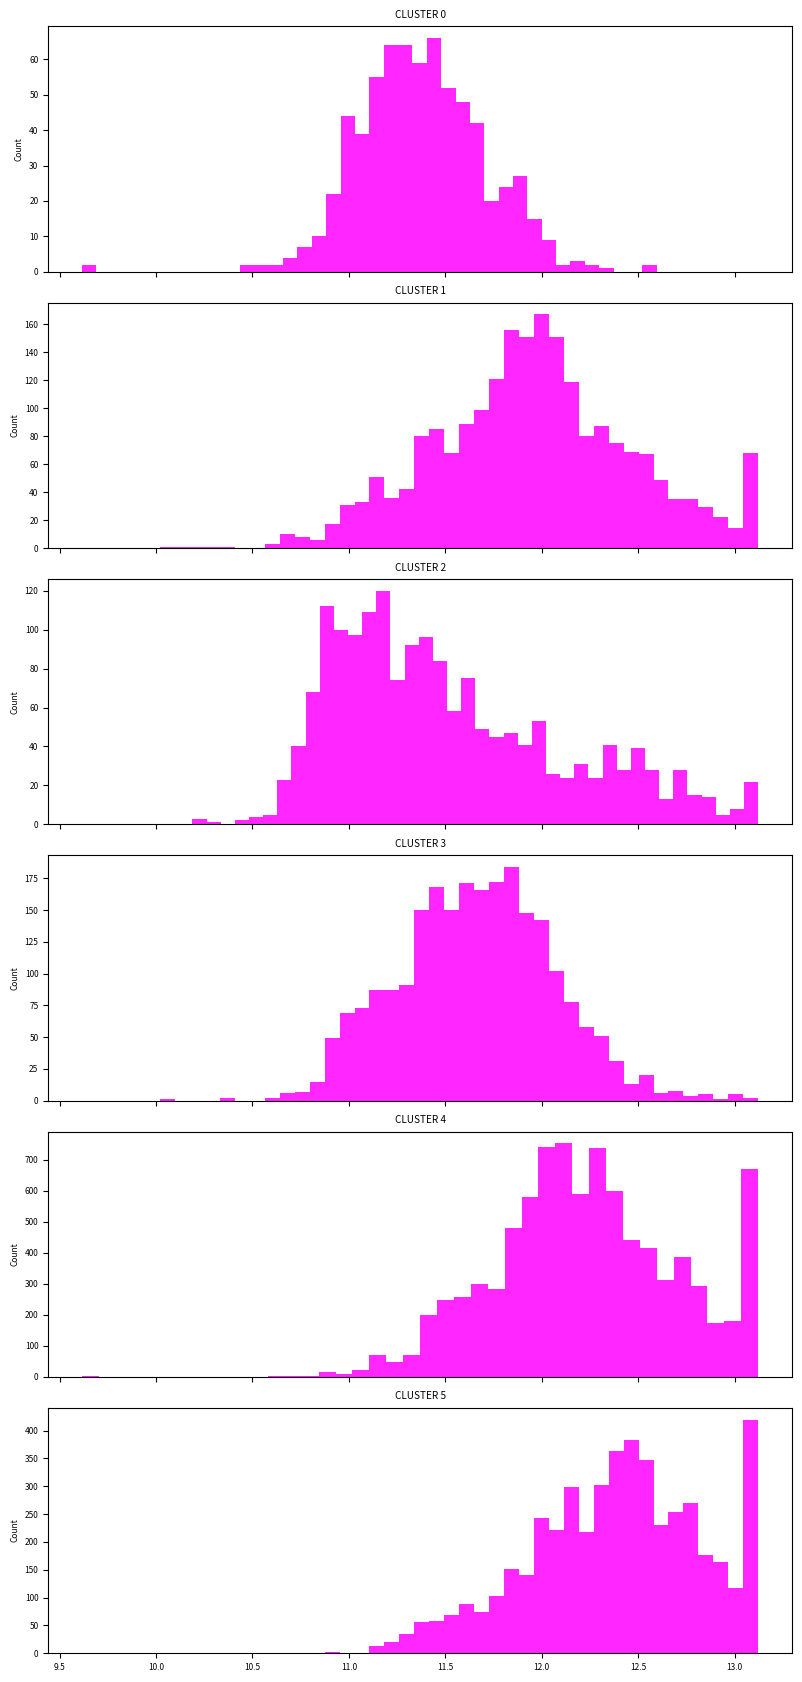

In [197]:
clusters = sorted(df["CLUSTER_ID"].unique())
n = len(clusters)

fig, axes = plt.subplots(n, 1, figsize=(8, 2.8*n), sharex=True,)

for ax, cid in zip(axes, clusters):
    sub = df[df["CLUSTER_ID"] == cid]["log_median_hou"].dropna()
    
    ax.hist(sub, bins=40, color="magenta", alpha=0.85)
    ax.set_title(f"CLUSTER {cid}")
    ax.set_ylabel("Count")



plt.tight_layout()
plt.show()


**가설**

NEAR OCEAN, ISLAND일 때

In [173]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,...,log_house_value,log_income,log_population,sqrt_population,ocean_INLAND,ocean_ISLAND,ocean_NEAR BAY,ocean_NEAR OCEAN,post_1940,income_quartile
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY,...,13.022766,2.232720,5.777652,17.944358,False,False,True,False,1,High
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY,...,12.789687,2.230165,7.784057,49.000000,False,False,True,False,1,High
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY,...,12.771673,2.111110,6.208590,22.271057,False,False,True,False,0,High
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY,...,12.740520,1.893579,6.326149,23.622024,False,False,True,False,0,High
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY,...,12.743154,1.578195,6.338594,23.769729,False,False,True,False,0,Mid-High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25,1665,374.0,845,330,1.5603,78100,INLAND,...,11.265758,0.940124,6.740519,29.068884,True,False,False,False,1,Low
20636,-121.21,39.49,18,697,150.0,356,114,2.5568,77100,INLAND,...,11.252872,1.268861,5.877736,18.867962,True,False,False,False,1,Low
20637,-121.22,39.43,17,2254,485.0,1007,433,1.7000,92300,INLAND,...,11.432810,0.993252,6.915723,31.733263,True,False,False,False,1,Low
20638,-121.32,39.43,18,1860,409.0,741,349,1.8672,84700,INLAND,...,11.346883,1.053336,6.609349,27.221315,True,False,False,False,1,Low


In [198]:
import numpy as np
import pandas as pd
from scipy import stats

# ===============================
# 1. 분석 대상 필터링
# ===============================

target = df[
    (df["CLUSTER_ID"].isin([4, 5])) &
    (df["ocean_prox"].isin(["NEAR OCEAN", "ISLAND"]))
][["CLUSTER_ID", "median_hou"]].dropna()

# CLUSTER별 분리
south = target[target["CLUSTER_ID"] == 4]["median_hou"]  # 남부해안
north = target[target["CLUSTER_ID"] == 5]["median_hou"]  # 북부해안

# ===============================
# 2. Welch 단측 t-검정
# ===============================

t_stat, p_two = stats.ttest_ind(
    south,
    north,
    equal_var=False,
    nan_policy="omit"
)

# 단측 p-value (남부 > 북부)
p_one = p_two / 2 if t_stat > 0 else 1.0
alpha = 0.05

# ===============================
# 3. 요약 통계
# ===============================

mean_south = south.mean()
mean_north = north.mean()
n_south = south.shape[0]
n_north = north.shape[0]

# ===============================
# 4. 결과 해석
# ===============================

if p_one < alpha:
    decision = "귀무가설을 기각한다."
    conclusion = (
        "NEAR BAY 및 ISLAND 조건에서 "
        "남부해안(CLUSTER 4)의 주택가격이 "
        "북부해안(CLUSTER 5)보다 통계적으로 유의미하게 높다."
    )
else:
    decision = "귀무가설을 기각하지 못한다."
    conclusion = (
        "NEAR BAY 및 ISLAND 조건에서 "
        "남부해안(CLUSTER 4)의 주택가격이 "
        "북부해안(CLUSTER 5)보다 높다고 통계적으로 단정하기 어렵다."
    )

# ===============================
# 5. 보고서용 문자열 출력
# ===============================

report = f"""
[CLUSTER 4 vs CLUSTER 5 | NEAR BAY & ISLAND 주택가격 가설검정]

1. 가설
- H₀: NEAR BAY·ISLAND 조건에서 CLUSTER 4와 CLUSTER 5의 평균 주택가격은 같다.
- H₁: NEAR BAY·ISLAND 조건에서 CLUSTER 4의 평균 주택가격이 CLUSTER 5보다 높다.

2. 표본 수
- CLUSTER 4 (남부해안): {n_south}
- CLUSTER 5 (북부해안): {n_north}

3. 평균 주택가격
- CLUSTER 4 평균: {mean_south:,.0f}
- CLUSTER 5 평균: {mean_north:,.0f}

4. 검정 통계량
- t 통계량: {t_stat:.3f}
- 단측 p-value: {p_one:.4f}
- 유의수준 α = {alpha}

5. 검정 결과
- 판단: {decision}
- 결론: {conclusion}

본 검정은 해안 접근성(ocean proximity)을 NEAR OCEAN 및 ISLAND로 고정한 상태에서,
지리적 군집(CLUSTER) 자체가 주택가격에 미치는 영향을 검증한 결과이다.
"""

print(report)




[CLUSTER 4 vs CLUSTER 5 | NEAR BAY & ISLAND 주택가격 가설검정]

1. 가설
- H₀: NEAR BAY·ISLAND 조건에서 CLUSTER 4와 CLUSTER 5의 평균 주택가격은 같다.
- H₁: NEAR BAY·ISLAND 조건에서 CLUSTER 4의 평균 주택가격이 CLUSTER 5보다 높다.

2. 표본 수
- CLUSTER 4 (남부해안): 580
- CLUSTER 5 (북부해안): 684

3. 평균 주택가격
- CLUSTER 4 평균: 282,248
- CLUSTER 5 평균: 322,512

4. 검정 통계량
- t 통계량: -6.251
- 단측 p-value: 1.0000
- 유의수준 α = 0.05

5. 검정 결과
- 판단: 귀무가설을 기각하지 못한다.
- 결론: NEAR BAY 및 ISLAND 조건에서 남부해안(CLUSTER 4)의 주택가격이 북부해안(CLUSTER 5)보다 높다고 통계적으로 단정하기 어렵다.

본 검정은 해안 접근성(ocean proximity)을 NEAR OCEAN 및 ISLAND로 고정한 상태에서,
지리적 군집(CLUSTER) 자체가 주택가격에 미치는 영향을 검증한 결과이다.



**1940년 이전 주택(52)만 가설검정**

In [199]:
from scipy import stats

# ===============================
# 1. 필터링
# ===============================

old_house = df[
    (df["CLUSTER_ID"].isin([4, 5])) &
    (df["ocean_prox"].isin(["NEAR OCEAN", "ISLAND"])) &
    (df["housing_me"] == 52)
][["CLUSTER_ID", "median_hou"]].dropna()

south_old = old_house[old_house["CLUSTER_ID"] == 4]["median_hou"]
north_old = old_house[old_house["CLUSTER_ID"] == 5]["median_hou"]

# ===============================
# 2. Welch 단측 t-test
# ===============================

t_old, p2_old = stats.ttest_ind(
    south_old, north_old, equal_var=False, nan_policy="omit"
)

p1_old = p2_old / 2 if t_old > 0 else 1.0
alpha = 0.05

# ===============================
# 3. 결과 출력
# ===============================

print(f"""
[1940년 이전 주택 (HouseAge = 52) 가설검정]

- CLUSTER 4 표본 수: {south_old.shape[0]}
- CLUSTER 5 표본 수: {north_old.shape[0]}

- CLUSTER 4 평균: {south_old.mean():,.0f}
- CLUSTER 5 평균: {north_old.mean():,.0f}

- t 통계량: {t_old:.3f}
- 단측 p-value: {p1_old:.4f}

결론: {"귀무가설 기각 (남부해안이 더 비쌈)" if p1_old < alpha else "유의하지 않음"}
""")



[1940년 이전 주택 (HouseAge = 52) 가설검정]

- CLUSTER 4 표본 수: 26
- CLUSTER 5 표본 수: 52

- CLUSTER 4 평균: 295,165
- CLUSTER 5 평균: 344,237

- t 통계량: -1.982
- 단측 p-value: 1.0000

결론: 유의하지 않음



**1940년 이후 주택(<52)만 가설검정**

In [200]:
new_house = df[
    (df["CLUSTER_ID"].isin([4, 5])) &
    (df["ocean_prox"].isin(["NEAR OCEAN", "ISLAND"])) &
    (df["housing_me"] < 52)
][["CLUSTER_ID", "median_hou"]].dropna()

south_new = new_house[new_house["CLUSTER_ID"] == 4]["median_hou"]
north_new = new_house[new_house["CLUSTER_ID"] == 5]["median_hou"]

t_new, p2_new = stats.ttest_ind(
    south_new, north_new, equal_var=False, nan_policy="omit"
)

p1_new = p2_new / 2 if t_new > 0 else 1.0

print(f"""
[1940년 이후 주택 (HouseAge < 52) 가설검정]

- CLUSTER 4 표본 수: {south_new.shape[0]}
- CLUSTER 5 표본 수: {north_new.shape[0]}

- CLUSTER 4 평균: {south_new.mean():,.0f}
- CLUSTER 5 평균: {north_new.mean():,.0f}

- t 통계량: {t_new:.3f}
- 단측 p-value: {p1_new:.4f}

결론: {"귀무가설 기각 (남부해안이 더 비쌈)" if p1_new < alpha else "유의하지 않음"}
""")



[1940년 이후 주택 (HouseAge < 52) 가설검정]

- CLUSTER 4 표본 수: 554
- CLUSTER 5 표본 수: 632

- CLUSTER 4 평균: 281,641
- CLUSTER 5 평균: 320,724

- t 통계량: -5.896
- 단측 p-value: 1.0000

결론: 유의하지 않음



군집 간 비교

In [201]:
import numpy as np
import pandas as pd
from scipy import stats

# ===============================
# 1. 분석 데이터 준비
# ===============================

# CLUSTER 4, 5만 선택
df_test = df[df["CLUSTER_ID"].isin([4, 5])].copy()

# 로그 주택가격 (이미 있다면 이 줄 생략)
df_test["log_median_hou"] = np.log(df_test["median_hou"])

# 군집별 데이터
c4 = df_test[df_test["CLUSTER_ID"] == 4]["log_median_hou"].dropna()
c5 = df_test[df_test["CLUSTER_ID"] == 5]["log_median_hou"].dropna()

# ===============================
# 2. Welch 단측 t-검정
# ===============================

t_stat, p_two = stats.ttest_ind(
    c4,
    c5,
    equal_var=False,
    nan_policy="omit"
)

# 단측 p-value (CLUSTER 4 > CLUSTER 5)
p_one = p_two / 2 if t_stat > 0 else 1.0
alpha = 0.05

# ===============================
# 3. 요약 통계
# ===============================

mean_c4 = c4.mean()
mean_c5 = c5.mean()
n_c4 = c4.shape[0]
n_c5 = c5.shape[0]

# ===============================
# 4. 결론 판정
# ===============================

if p_one < alpha:
    decision = "귀무가설을 기각한다."
    conclusion = (
        "CLUSTER 4의 평균 주택가격이 CLUSTER 5보다 "
        "통계적으로 유의미하게 높다."
    )
else:
    decision = "귀무가설을 기각하지 못한다."
    conclusion = (
        "CLUSTER 4의 평균 주택가격이 CLUSTER 5보다 "
        "높다고 통계적으로 단정하기 어렵다."
    )

# ===============================
# 5. 문자열 보고서 출력
# ===============================

report = f"""
[CLUSTER 4 vs CLUSTER 5 주택가격 가설검정 결과]

1. 가설 설정
- H₀: CLUSTER 4와 CLUSTER 5의 평균 주택가격은 동일하다.
- H₁: CLUSTER 4의 평균 주택가격이 CLUSTER 5보다 높다.

2. 표본 수
- CLUSTER 4 표본 수: {n_c4}
- CLUSTER 5 표본 수: {n_c5}

3. 평균 주택가격 (로그 기준)
- CLUSTER 4 평균: {mean_c4:.3f}
- CLUSTER 5 평균: {mean_c5:.3f}

4. 검정 통계량
- t 통계량: {t_stat:.3f}
- 단측 p-value: {p_one:.4f}
- 유의수준 α = {alpha}

5. 검정 결과
- 판단: {decision}
- 결론: {conclusion}

"""

print(report)



[CLUSTER 4 vs CLUSTER 5 주택가격 가설검정 결과]

1. 가설 설정
- H₀: CLUSTER 4와 CLUSTER 5의 평균 주택가격은 동일하다.
- H₁: CLUSTER 4의 평균 주택가격이 CLUSTER 5보다 높다.

2. 표본 수
- CLUSTER 4 표본 수: 8899
- CLUSTER 5 표본 수: 4826

3. 평균 주택가격 (로그 기준)
- CLUSTER 4 평균: 12.232
- CLUSTER 5 평균: 12.383

4. 검정 통계량
- t 통계량: -18.247
- 단측 p-value: 1.0000
- 유의수준 α = 0.05

5. 검정 결과
- 판단: 귀무가설을 기각하지 못한다.
- 결론: CLUSTER 4의 평균 주택가격이 CLUSTER 5보다 높다고 통계적으로 단정하기 어렵다.




CLUSTER_ID관측치별 공간분포시각화

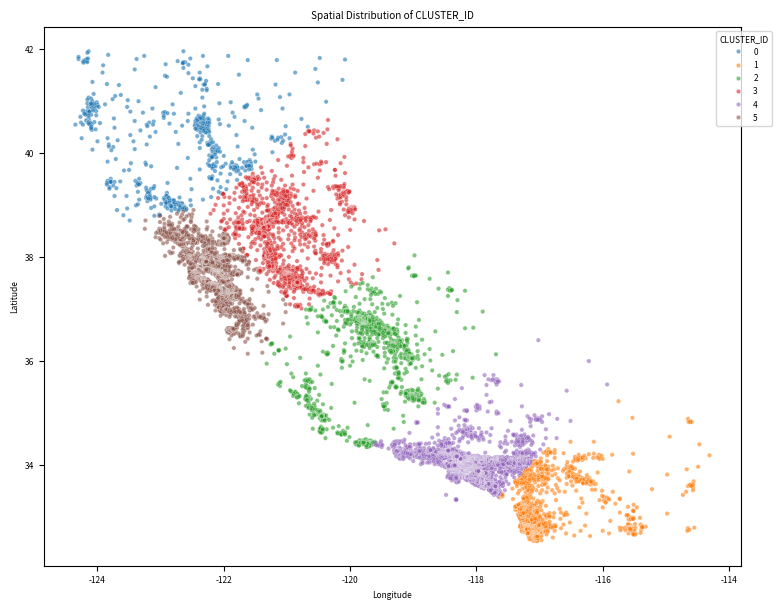

In [202]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 7))
sns.scatterplot(
    data=df,
    x="longitude",
    y="latitude",
    hue="CLUSTER_ID",
    palette="tab10",
    s=10,
    alpha=0.6
)

plt.title("Spatial Distribution of CLUSTER_ID")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="CLUSTER_ID", bbox_to_anchor=(1.05, 1))
plt.show()


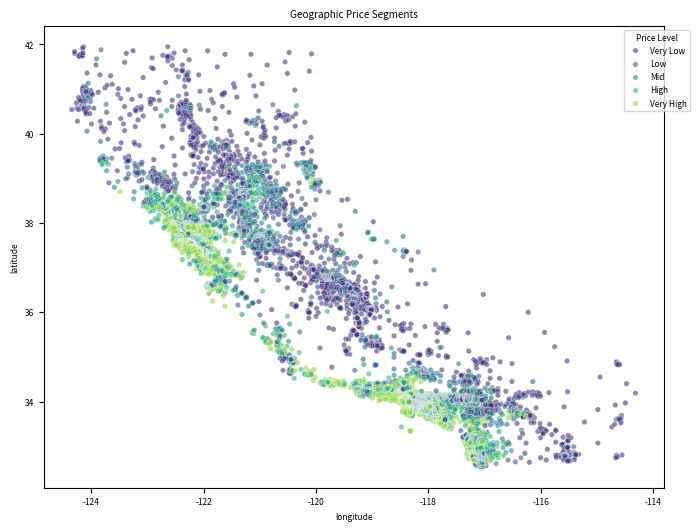

In [203]:
# 산점도 + 가격 구간 색상 분리
df["price_bin"] = pd.qcut(
    df["median_hou"],
    q=5,
    labels=["Very Low", "Low", "Mid", "High", "Very High"]
)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="longitude",
    y="latitude",
    hue="price_bin",
    palette="viridis",
    s=15,
    alpha=0.6
)

plt.title("Geographic Price Segments")
plt.legend(title="Price Level", bbox_to_anchor=(1.05, 1))
plt.show()


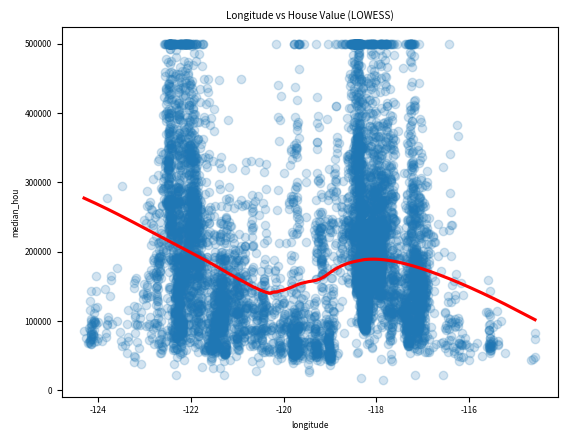

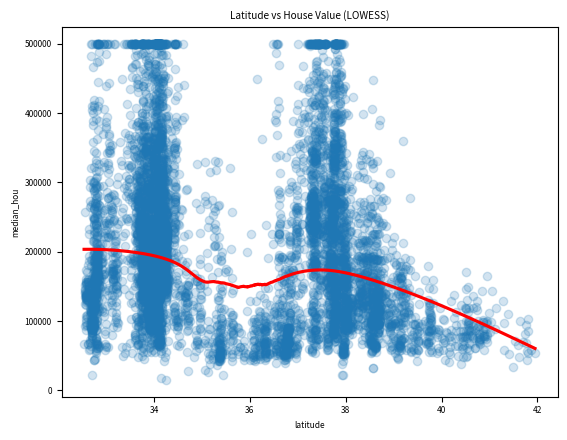

Longitude vs House Value에서 왜 내륙 지역에서 집값이 올라가냐?
조건부 변수 때문에
📌 따라서 LOWESS 곡선의 국소적 상승은**“그 경도에 어떤 지역들이 몰려 있느냐”**를 반영한다.



In [204]:
# 위치 vs 가격: 비선형성 확인
sns.regplot(
    data=df.sample(8000, random_state=42),
    x="longitude",
    y="median_hou",
    lowess=True,
    scatter_kws={"alpha": 0.2},
    line_kws={"color": "red"}
)
plt.title("Longitude vs House Value (LOWESS)")
plt.show()
sns.regplot(
    data=df.sample(8000, random_state=42),
    x="latitude",
    y="median_hou",
    lowess=True,
    scatter_kws={"alpha": 0.2},
    line_kws={"color": "red"}
)
plt.title("Latitude vs House Value (LOWESS)")
plt.show()
print(f"Longitude vs House Value에서 왜 내륙 지역에서 집값이 올라가냐?\n조건부 변수 때문에\n📌 따라서 LOWESS 곡선의 국소적 상승은**“그 경도에 어떤 지역들이 몰려 있느냐”**를 반영한다.")
print(f"")

In [205]:
# 상관계수로 보면 왜 “위치가 약해 보이는지”
sangwan = df[[
    "latitude",
    "longitude",
    "median_hou"
]].corr()
print(f"위도·경도는 가격과 강한 비선형 관계를 가지므로\n단순 Pearson 상관계수는 위치 효과를 과소평가한다.")
print(f"하지만 latitude와 median_house_value간의 음의 상관계수가 다소 강한 것으로 보아,  북쪽에 위치한 집일수록 집값이 저렴하다는 것을 알 수 있다.")
print(f"즉, 북쪽 해변이 집값이 저렴")
print(sangwan)

위도·경도는 가격과 강한 비선형 관계를 가지므로
단순 Pearson 상관계수는 위치 효과를 과소평가한다.
하지만 latitude와 median_house_value간의 음의 상관계수가 다소 강한 것으로 보아,  북쪽에 위치한 집일수록 집값이 저렴하다는 것을 알 수 있다.
즉, 북쪽 해변이 집값이 저렴
            latitude  longitude  median_hou
latitude    1.000000  -0.924664   -0.144160
longitude  -0.924664   1.000000   -0.045967
median_hou -0.144160  -0.045967    1.000000


## dist_to_city 변수 로드

In [292]:
# 토지 독점력 지표 생성 (Distance 기반)


COAST_LON = -120  # 해안 근사 기준선 (캘리포니아 평균 해안 경도)

df["dist_to_coast"] = np.abs(df["longitude"] - COAST_LON)

In [293]:
# 주요 해안·도심 축 거리 (SF / LA)


sf_lat, sf_lon = 37.77, -122.42                 # 주요 해안 도시 좌표
la_lat, la_lon = 34.05, -118.25      


df["dist_to_sf"] = np.sqrt(
    (df["latitude"] - sf_lat)**2 + (df["longitude"] - sf_lon)**2
)

df["dist_to_la"] = np.sqrt(
    (df["latitude"] - la_lat)**2 + (df["longitude"] - la_lon)**2
)

# 더 가까운 쪽을 대표 도심 거리로 사용
df["dist_to_city"] = df[["dist_to_sf", "dist_to_la"]].min(axis=1)


In [294]:
# 2️⃣ 토지 독점력 구간화 (핵심)
# (1) 해안 독점력 구간 (분위수 기준)
df["coast_power"] = pd.qcut(
    df["dist_to_coast"],
    q=4,
    labels=[
        "Very High Land Dominance (Coastal)",
        "High",
        "Medium",
        "Low (Inland)"
    ]
)


In [295]:
# (2) 도심 독점력 구간
df["city_power"] = pd.qcut(
    df["dist_to_city"],
    q=4,
    labels=[
        "Core Urban",
        "Inner Urban",
        "Suburban",
        "Peripheral"
    ]
)



C:\Users\itwill\AppData\Local\Temp\ipykernel_21724\1505763526.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


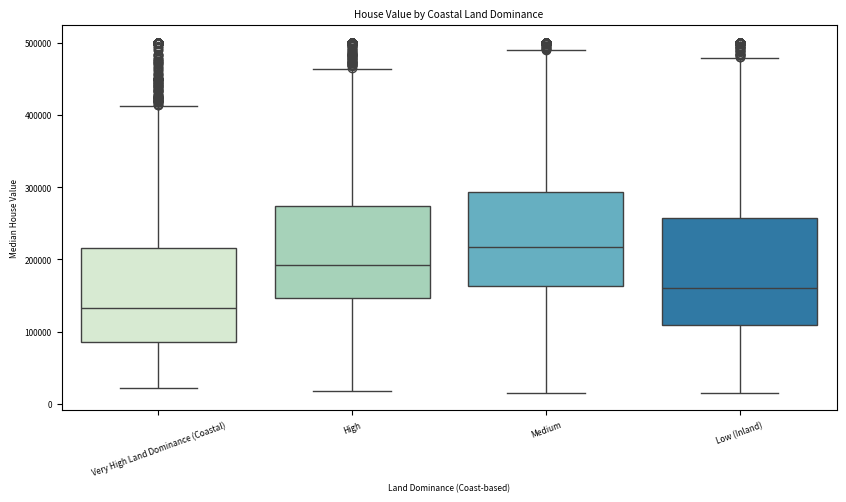

“해안이 가장 비싸야 하는데 왜 하단이 싸 보이지?”
1️⃣ 가장 중요한 1차 원인
🔹 A. 초고가 해안 (SF, Malibu, Santa Monica)
토지 희소성 ↑
고소득 수요 ↑
가격 상단 형성
🔹 B. 저가 해안 (Central Valley 인근, 낙후된 해안 소도시)
관광지 아님
산업·항만·농업 연계
주거 수요 낮음📌 Very High Land Dominance는 ‘해안 접근성’만 반영
→ ‘부촌 여부’는 반영하지 않음
👉 전형적인 ‘혼합 분포(mixture distribution)’

2️⃣ 2차 원인
Very High Land Dominance는:
“바다와 가깝다”는 뜻이지
“살기 좋은 동네다”는 뜻이 아니다
해안에는 다음도 많다:
오래된 주택
🍭저소득 어업·항만 노동자 주거지🍭
🍭관광 비수기 지역🍭

3️⃣ 3차 원인
Very High 그룹은:
분산이 가장 큼
저가 해안이 포함되면
→ Q1이 급격히 내려감
반면:
High / Medium 그룹은
내륙 도시 위주
가격 분포가 더 균질
Q1이 상대적으로 높아 보임
📌 이건 역설이 아니라:
분산이 클수록 Q1은 내려간다
라는 통계적 성질


In [296]:
# (1) 해안 독점력별 가격 분포
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df,
    x="coast_power",
    y="median_house_value",
    palette = "GnBu"
)
plt.xticks(rotation=20)
plt.title("House Value by Coastal Land Dominance")
plt.ylabel("Median House Value")
plt.xlabel("Land Dominance (Coast-based)")
plt.show()
print(f"“해안이 가장 비싸야 하는데 왜 하단이 싸 보이지?”")
print(f"1️⃣ 가장 중요한 1차 원인\n🔹 A. 초고가 해안 (SF, Malibu, Santa Monica)\n토지 희소성 ↑\n고소득 수요 ↑\n가격 상단 형성\n🔹 B. 저가 해안 (Central Valley 인근, 낙후된 해안 소도시)\n관광지 아님\n산업·항만·농업 연계\n주거 수요 낮음📌 Very High Land Dominance는 ‘해안 접근성’만 반영\n→ ‘부촌 여부’는 반영하지 않음\n👉 전형적인 ‘혼합 분포(mixture distribution)’\n")
print(f"2️⃣ 2차 원인\nVery High Land Dominance는:\n“바다와 가깝다”는 뜻이지\n“살기 좋은 동네다”는 뜻이 아니다\n해안에는 다음도 많다:\n오래된 주택\n🍭저소득 어업·항만 노동자 주거지🍭\n🍭관광 비수기 지역🍭\n")
print(f"3️⃣ 3차 원인\nVery High 그룹은:\n분산이 가장 큼\n저가 해안이 포함되면\n→ Q1이 급격히 내려감")
print(f"반면:\nHigh / Medium 그룹은\n내륙 도시 위주\n가격 분포가 더 균질\nQ1이 상대적으로 높아 보임\n📌 이건 역설이 아니라:\n분산이 클수록 Q1은 내려간다\n라는 통계적 성질")

3️⃣ 토지 독점력 × 주택 중위가격 매칭

In [297]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   longitude           20640 non-null  float64 
 1   latitude            20640 non-null  float64 
 2   housing_median_age  20640 non-null  int64   
 3   total_rooms         20640 non-null  int64   
 4   total_bedrooms      20433 non-null  float64 
 5   population          20640 non-null  int64   
 6   households          20640 non-null  int64   
 7   median_income       20640 non-null  float64 
 8   median_house_value  20640 non-null  int64   
 9   ocean_proximity     20640 non-null  object  
 10  CLUSTER_ID          20640 non-null  int64   
 11  city                1050 non-null   object  
 12  is_capped           20640 non-null  int64   
 13  income_quartile     20640 non-null  category
 14  income_bin          20640 non-null  category
 15  post_1940           20640 non-null  

C:\Users\itwill\AppData\Local\Temp\ipykernel_21724\2473213424.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


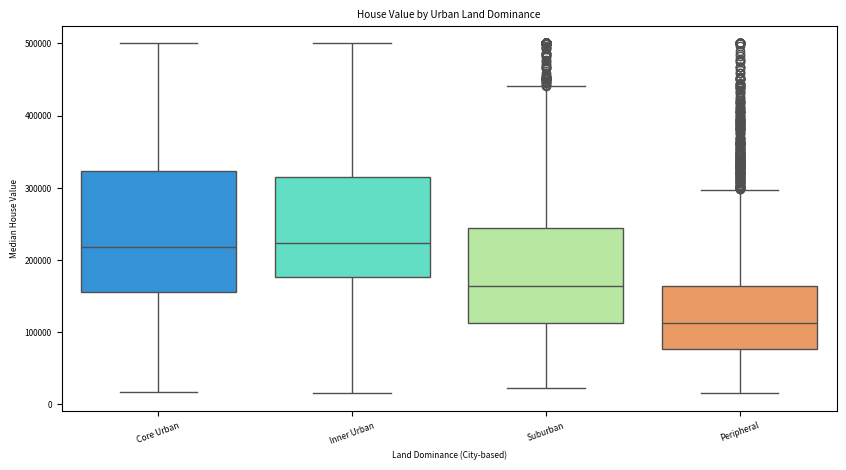

In [298]:
# (2) 도심 독점력별 가격 분포
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df,
    x="city_power",
    y="median_house_value",
    palette = "rainbow"
)
plt.xticks(rotation=20)
plt.title("House Value by Urban Land Dominance")
plt.ylabel("Median House Value")
plt.xlabel("Land Dominance (City-based)")
plt.show()


## 가설 A (분포 하단 검증 – 핵심)

H₀ (귀무가설)
Peripheral 지역과 Urban 지역의 하위 가격대(Q1) 는 차이가 없다.

H₁ (대립가설)
Peripheral 지역의 하위 가격대(Q1) 가 Urban 지역보다 낮다.

→ 왜 평균이 아니라 Q1?
👉 “사분위 시작 구간이 낮다”는 시각적 주장과 정확히 일치

In [257]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu

# =========================
# 1. 데이터 준비
# =========================
df_test = df[
    df["city_power"].isin(["Peripheral", "Core Urban", "Inner Urban"])
].copy()

peripheral = df_test[df_test["city_power"] == "Peripheral"]["median_house_value"]
urban = df_test[df_test["city_power"].isin(["Core Urban", "Inner Urban"])]["median_house_value"]

# =========================
# 2. Mann–Whitney U Test (단측)
# =========================
u_stat, p_two = mannwhitneyu(
    peripheral,
    urban,
    alternative="less"   # Peripheral < Urban
)

# =========================
# 3. 사분위수 비교
# =========================
q1_peripheral = np.percentile(peripheral, 25)
q1_urban = np.percentile(urban, 25)

# =========================
# 4. 결과 해석
# =========================
if p_two < 0.01:
    sig = "매우 유의미하다 (p < 0.01)"
elif p_two < 0.05:
    sig = "유의미하다 (p < 0.05)"
else:
    sig = "통계적으로 유의하지 않다"

report = f"""
[Peripheral 해안 지역 하위 가격대 검증 결과]

Peripheral 지역의 1사분위(Q1) 주택가격은 {q1_peripheral:,.0f},
Urban(Core/Inner) 지역의 1사분위는 {q1_urban:,.0f}로 나타났다.

Mann–Whitney U 단측 검정 결과,
U-statistic = {u_stat:,.0f}
p-value = {p_two:.4f}

따라서 Peripheral 지역의 하위 주택가격대는
Urban 지역보다 {sig} 수준으로 낮다.

이는 해안 프리미엄이 지역 전체에 균등하게 작용하지 않고,
일부 고급 enclave에만 집중된다는 가설을 지지한다.
"""

print(report)



[Peripheral 해안 지역 하위 가격대 검증 결과]

Peripheral 지역의 1사분위(Q1) 주택가격은 75,975,
Urban(Core/Inner) 지역의 1사분위는 164,600로 나타났다.

Mann–Whitney U 단측 검정 결과,
U-statistic = 9,408,755
p-value = 0.0000

따라서 Peripheral 지역의 하위 주택가격대는
Urban 지역보다 매우 유의미하다 (p < 0.01) 수준으로 낮다.

이는 해안 프리미엄이 지역 전체에 균등하게 작용하지 않고,
일부 고급 enclave에만 집중된다는 가설을 지지한다.



Peripheral 지역은 해안 인접이라는 이점을 지니지만,<br>주택가격 분포의 하위 사분위는 도시 중심 지역보다 유의미하게 낮다.<br> 이는 해안 프리미엄이 지역 전반이 아닌 일부 고급 주거지에만 집중됨을 시사한다.

🍭지역별 주택 중위가격 분석 결과

In [258]:
import pandas as pd

# 1. 데이터 불러오기
df = origin.copy()

# 2. 좌표 기반으로 도시 라벨링 함수 정의 (각 도시의 대략적인 범위 설정)
def classify_city(row):
    lon, lat = row['longitude'], row['latitude']
    
    # 말리부 (초고가)
    if -119.0 <= lon <= -118.6 and 34.0 <= lat <= 34.1:
        return 'Malibu'
    # 샌타모니카 (고가)
    elif -118.55 <= lon <= -118.4 and 33.98 <= lat <= 34.06:
        return 'Santa Monica'
    # 샌피드로 (저가 해안)
    elif -118.35 <= lon <= -118.25 and 33.70 <= lat <= 33.77:
        return 'San Pedro'
    # 롱비치 (저가 해안)
    elif -118.25 <= lon <= -118.05 and 33.74 <= lat <= 33.9:
        return 'Long Beach'
    return None

# 3. 도시 분류 적용 및 필터링
df['city'] = df.apply(classify_city, axis=1)
target_df = df[df['city'].notnull()].copy()

# 4. 분석 그룹 추가 (시각화 시 색상 구분을 위해)
high_cost = ['Malibu', 'Santa Monica']
target_df['group'] = target_df['city'].apply(lambda x: 'Ultra-High' if x in high_cost else 'Affordable')

# 5. QGIS용 파일 저장 및 결과 출력
target_df.to_csv('coastal_analysis.csv', index=False)

print("--- 지역별 주택 중위가격 분석 결과 ---")
summary = target_df.groupby('city')['median_house_value'].median().sort_values(ascending=False)
print(summary)
print(f"똑같은 해안지역임에도 불고하고 각 해안마다 주택가격 차이가 난다는 것을 알 수 있었다")
print(f"San Pedro와 Long Beach는 Malibu에 비해서 아래쪽에 위치하는데도 불구하고 왜 Malibu보다 주택가격이 더 낮을까?")

--- 지역별 주택 중위가격 분석 결과 ---
city
Malibu          500001.0
Santa Monica    394700.0
San Pedro       274900.0
Long Beach      194000.0
Name: median_house_value, dtype: float64
똑같은 해안지역임에도 불고하고 각 해안마다 주택가격 차이가 난다는 것을 알 수 있었다
San Pedro와 Long Beach는 Malibu에 비해서 아래쪽에 위치하는데도 불구하고 왜 Malibu보다 주택가격이 더 낮을까?


## 📍 지역별 비교: 북서쪽(Malibu) vs 남동쪽(San Pedro/Long Beach)

| 구분 | 말리부(Malibu) / 산타모니카(Santa Monica) | 샌페드로(San Pedro) / 롱비치(Long Beach) |
| :--- | :--- | :--- |
| **주요 시설** | 고급 주택가, 관광지, 테크 오피스 | 세계적 규모의 무역항 (Port of LA/LB) |
| **분위기** | 조용함, 자연 친화적, 프라이빗 | 활동적, 산업적, 교통 혼잡 |
| **결정적 단점** | 산불 위험, 높은 물가 | 환경 오염(항만 매연 등), 소음 |
| **지리적 특징** | 오픈 오션, 해안선이 좁고 산맥에 인접 | 방파제로 둘러싸인 항구, 평지 위주 |

## 가설:인구수(Population)가 많을수록 해당 지역이 더 산업적(주택 가격이 낮음)일 것이다.

--- 통계적 가설 검정 결과 ---
상관계수(Correlation Coefficient): -0.1227
p-value: 6.6864e-05
결과: p-value가 0.05보다 작으므로, 인구수와 주택 가격 간의 관계는 통계적으로 유의미합니다.


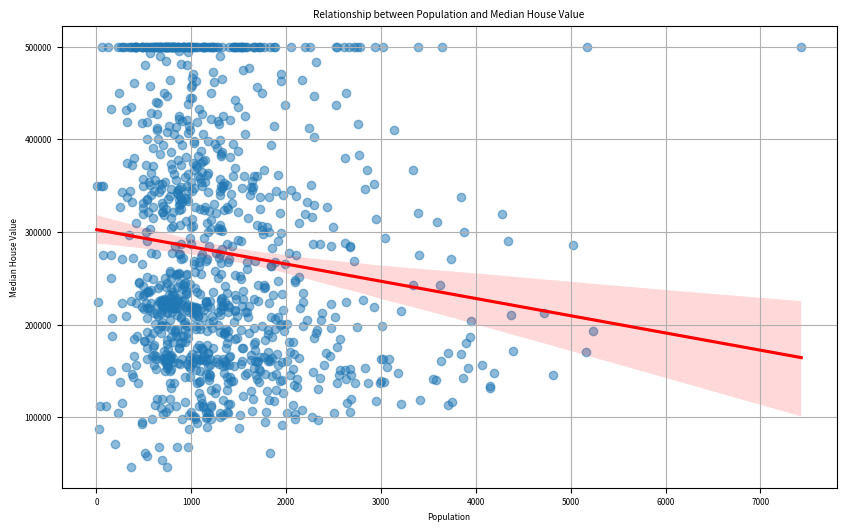


--- 그룹별 인구수 평균 비교 ---
group
Affordable    1378.566434
Ultra-High    1183.444776
Name: population, dtype: float64


In [259]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 준비 (앞선 단계에서 생성한 target_df 활용)
# 가설: 인구수(population)가 많을수록 주택 가격(median_house_value)이 낮을 것이다 (음의 상관관계)

# 2. 상관계수(Correlation) 및 p-value 계산
# pearsonr은 선형적인 상관관계를 측정하며, p-value가 0.05보다 작으면 통계적으로 유의미하다고 봅니다.
corr, p_value = stats.pearsonr(target_df['population'], target_df['median_house_value'])

print(f"--- 통계적 가설 검정 결과 ---")
print(f"상관계수(Correlation Coefficient): {corr:.4f}")
print(f"p-value: {p_value:.4e}")

if p_value < 0.05:
    print("결과: p-value가 0.05보다 작으므로, 인구수와 주택 가격 간의 관계는 통계적으로 유의미합니다.")
else:
    print("결과: p-value가 0.05보다 크므로, 통계적으로 유의미한 관계를 찾기 어렵습니다.")

# 3. 시각화 (산점도 및 회귀선)
plt.figure(figsize=(10, 6))
sns.regplot(data=target_df, x='population', y='median_house_value', 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

plt.title('Relationship between Population and Median House Value')
plt.xlabel('Population')
plt.ylabel('Median House Value')
plt.grid(True)
plt.show()

# 4. 그룹별 비교 (Ultra-High vs Affordable)
print(f"\n--- 그룹별 인구수 평균 비교 ---")
group_comparison = target_df.groupby('group')['population'].mean()
print(group_comparison)

Ultra-High:초고가 지역<br>
Affordable:상대적저가지역

## 소득 사분위에 상한 주택이 몰려 있는가?

_일반주택:0, 상한주택:1_

In [260]:
df["is_capped"] = (df["median_house_value"] == 500001).astype(int)

df["income_quartile"] = pd.qcut(
    df["median_income"],
    q=4,
    labels=["Low", "Mid-Low", "Mid-High", "High"]
)

cont_table = pd.crosstab(
    df["income_quartile"],
    df["is_capped"]
)

cont_table

is_capped,0,1
income_quartile,,
Low,5136,24
Mid-Low,5114,46
Mid-High,5035,125
High,4390,770


**보편적으로 일반 주택이 많지만, 두 그룹 사이에 통계적인 차이가 있는가?**

In [261]:
import pandas as pd
from scipy import stats

# 1. 일반 주택(0)과 상한 주택(1) 그룹 분리
group_0 = df[df['is_capped'] == 0]['population']
group_1 = df[df['is_capped'] == 1]['population']

# 2. 독립표본 t-검정 수행
# 두 그룹의 인구수 평균이 통계적으로 유의미하게 다른지 확인합니다.
t_stat, p_val = stats.ttest_ind(group_0, group_1, equal_var=False)

print(f"--- 일반 주택 vs 상한 주택 인구수 검정 ---")
print(f"일반 주택(0) 인구 평균: {group_0.mean():.2f}")
print(f"상한 주택(1) 인구 평균: {group_1.mean():.2f}")
print(f"t-통계량: {t_stat:.4f}")
print(f"p-value: {p_val:.4e}")

if p_val < 0.05:
    print("\n결과: 두 그룹 간의 인구수 차이는 통계적으로 유의미합니다.")
else:
    print("\n결과: 두 그룹 간의 인구수 차이는 우연일 가능성이 높습니다.")

--- 일반 주택 vs 상한 주택 인구수 검정 ---
일반 주택(0) 인구 평균: 1440.81
상한 주택(1) 인구 평균: 1112.81
t-통계량: 11.9614
p-value: 3.5522e-31

결과: 두 그룹 간의 인구수 차이는 통계적으로 유의미합니다.


# 🏠 캘리포니아 주택 가격 클러스터별 모델 분석 보고서

## 1. 통계적 가설 검정 요약
인구수와 주택 가격 사이의 관계 및 고가 주택 구역의 특성을 분석한 결과입니다.

| 분석 항목 | 결과 수치 | 통계적 유의성 (p-value) | 결론 |
| :--- | :--- | :--- | :--- |
| **인구수-가격 상관관계** | -0.1227 | 6.6864e-05 | 음의 상관관계 존재 (유의미) |
| **일반 vs 상한 인구 차이** | 1440 vs 1112 | 3.5522e-31 | **부촌일수록 인구수가 적음** |

📝미션 5. “소득은 정말로 집값을 결정할까?”MedInc(중위 가구 소득)에 따라 MedHouseValue가 다른지 시각화하고, 선형성과 강도를 평가한다.<br>산점도와 함께 회귀선을 그려 관계의 형태를 관찰하세요.<br>상관계수(Pearson)를 계산하고, “정말로 소득이 집값의 주 결정 요인인가?”를 비판적으로 생각해 보자.<br>소득 수준에 따른 주택가격 불평등 문제를 해석 관점에서 논의하세요.

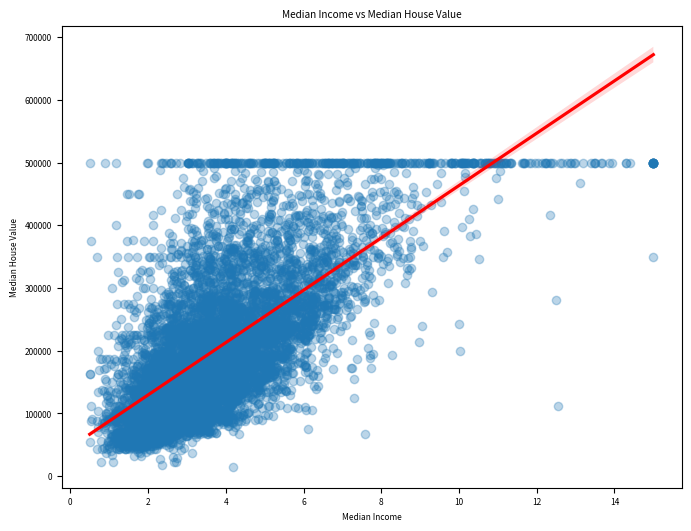

In [280]:
# 1️⃣ MedInc에 따른 MedHouseValue 산점도 + 회귀선
plt.figure(figsize=(8, 6))

sns.regplot(
    data=df.sample(8000, random_state=42),
    x="median_income",
    y="median_house_value",
    scatter_kws={"alpha": 0.3},
    line_kws={"color": "red"}
)

plt.title("Median Income vs Median House Value")
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.show()


C:\Users\itwill\AppData\Local\Temp\ipykernel_21724\2946070744.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


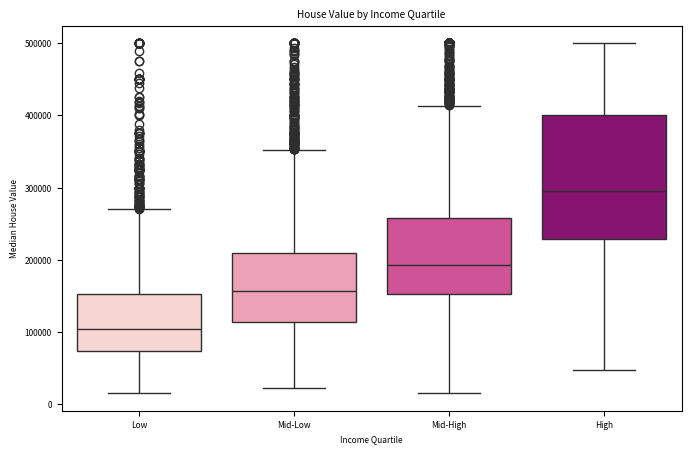

In [281]:
# 2️⃣ 소득 사분위수별 가격 분포
df["income_bin"] = pd.qcut(
    df["median_income"],
    q=4,
    labels=["Low", "Mid-Low", "Mid-High", "High"]
)

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="income_bin",
    y="median_house_value",
    palette="RdPu"
)

plt.title("House Value by Income Quartile")
plt.xlabel("Income Quartile")
plt.ylabel("Median House Value")
plt.show()


In [282]:
# 사분위수를 보고 Low가 다른 변수들 보다 높은 이상치들이 있다는 것을 발견
# 실제로 가장 높은 가격에 속하는 500001 달러의 주택이 고소득 구간이라는 것을 확인


# -----코드 설명-----
# 가격 상한(포화) 주택만 추출


cap_value = 500001
df_cap = df[df["median_house_value"] == cap_value]

print(f"상한 주택 수: {len(df_cap)}")


# 소득 사분위수 생성
df["income_quartile"] = pd.qcut(
    df["median_income"],
    q=4,
    labels=["Low", "Mid-Low", "Mid-High", "High"]
)

# 상한 주택에 분위 정보 붙이기
df_cap = df_cap.merge(
    df[["median_income", "income_quartile"]],
    left_index=True,
    right_index=True,
    how="left"
)



상한 주택 수: 965


In [283]:
# LA 대략적 경계 (보수적)
la_lat_min, la_lat_max = 33.5, 34.5
la_lon_min, la_lon_max = -118.8, -117.5

df_cap["is_LA"] = (
    (df_cap["latitude"].between(la_lat_min, la_lat_max)) &
    (df_cap["longitude"].between(la_lon_min, la_lon_max))
)


In [284]:
df_cap

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income_x,median_house_value,ocean_proximity,CLUSTER_ID,city,is_capped,income_quartile_x,income_bin,post_1940,median_income_y,income_quartile_y,is_LA
89,-122.27,37.80,52,249,78.0,396,85,1.2434,500001,NEAR BAY,5,None,1,Low,Low,0,1.2434,Low,False
459,-122.25,37.87,52,609,236.0,1349,250,1.1696,500001,NEAR BAY,5,None,1,Low,Low,0,1.1696,Low,False
493,-122.24,37.86,52,1668,225.0,517,214,7.8521,500001,NEAR BAY,5,None,1,High,High,0,7.8521,High,False
494,-122.24,37.85,52,3726,474.0,1366,496,9.3959,500001,NEAR BAY,5,None,1,High,High,0,9.3959,High,False
509,-122.23,37.83,52,2990,379.0,947,361,7.8772,500001,NEAR BAY,5,None,1,High,High,0,7.8772,High,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20422,-118.90,34.14,35,1503,263.0,576,216,5.1457,500001,<1H OCEAN,4,None,1,High,High,1,5.1457,High,False
20426,-118.69,34.18,11,1177,138.0,415,119,10.0472,500001,<1H OCEAN,4,None,1,High,High,1,10.0472,High,True
20427,-118.80,34.19,4,15572,2222.0,5495,2152,8.6499,500001,<1H OCEAN,4,None,1,High,High,1,8.6499,High,True
20436,-118.69,34.21,10,3663,409.0,1179,371,12.5420,500001,<1H OCEAN,4,None,1,High,High,1,12.5420,High,True


## 지역별(군집별) 상한 주택 분포

In [285]:
# 1️⃣ 전체 데이터 기준으로 소득 분위 생성
df["income_quartile"] = pd.qcut(
    df["median_income"],
    q=4,
    labels=["Low", "Mid-Low", "Mid-High", "High"]
)

# 2️⃣ 가격 상한 주택만 필터링
df_cap = df[df["median_house_value"] == 500001]

# 3️⃣ 이제 정상 작동
income_dist = (
    df_cap["income_quartile"]
    .value_counts(normalize=True)
    .sort_index()
)

print(income_dist)
print(f"상한만 제거했을 때 High에서 높은 값이 나타나는 것으로 보아, 중위소득과 인구는 양의 상관관계가 있음을 알 수 있음")

income_quartile
Low         0.024870
Mid-Low     0.047668
Mid-High    0.129534
High        0.797927
Name: proportion, dtype: float64
상한만 제거했을 때 High에서 높은 값이 나타나는 것으로 보아, 중위소득과 인구는 양의 상관관계가 있음을 알 수 있음


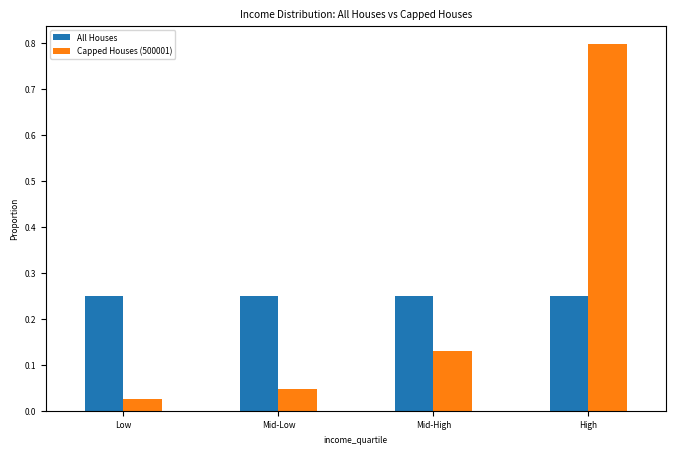

In [286]:
# 시각화: 상한 주택 vs 전체 비교
compare_df = pd.DataFrame({
    "All Houses": df["income_quartile"].value_counts(normalize=True),
    "Capped Houses (500001)": df_cap["income_quartile"].value_counts(normalize=True)
}).sort_index()

compare_df.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Income Distribution: All Houses vs Capped Houses")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.show()

In [287]:
# 1단계: 군집별 평균 위도·경도 계산
cluster_centroids = (
    df.groupby("CLUSTER_ID")[["latitude", "longitude"]]
      .mean()
      .reset_index()
)
cluster_centroids

,CLUSTER_ID,latitude,longitude
0,0,40.179536,-122.751437
1,1,33.053285,-116.937136
2,2,35.961479,-119.684220
3,3,38.396837,-121.135607
4,4,34.013568,-118.118596
5,5,37.669109,-122.172980


In [288]:
cluster_cap_summary = (
    df_cap.groupby("CLUSTER_ID")
    .size()
    .reset_index(name="cap_count")
    .sort_values("cap_count", ascending=False)
)

print(cluster_cap_summary)


   CLUSTER_ID  cap_count
3           4        546
4           5        346
0           1         51
1           2         21
2           3          1


KeyError: 'log_median_hou'

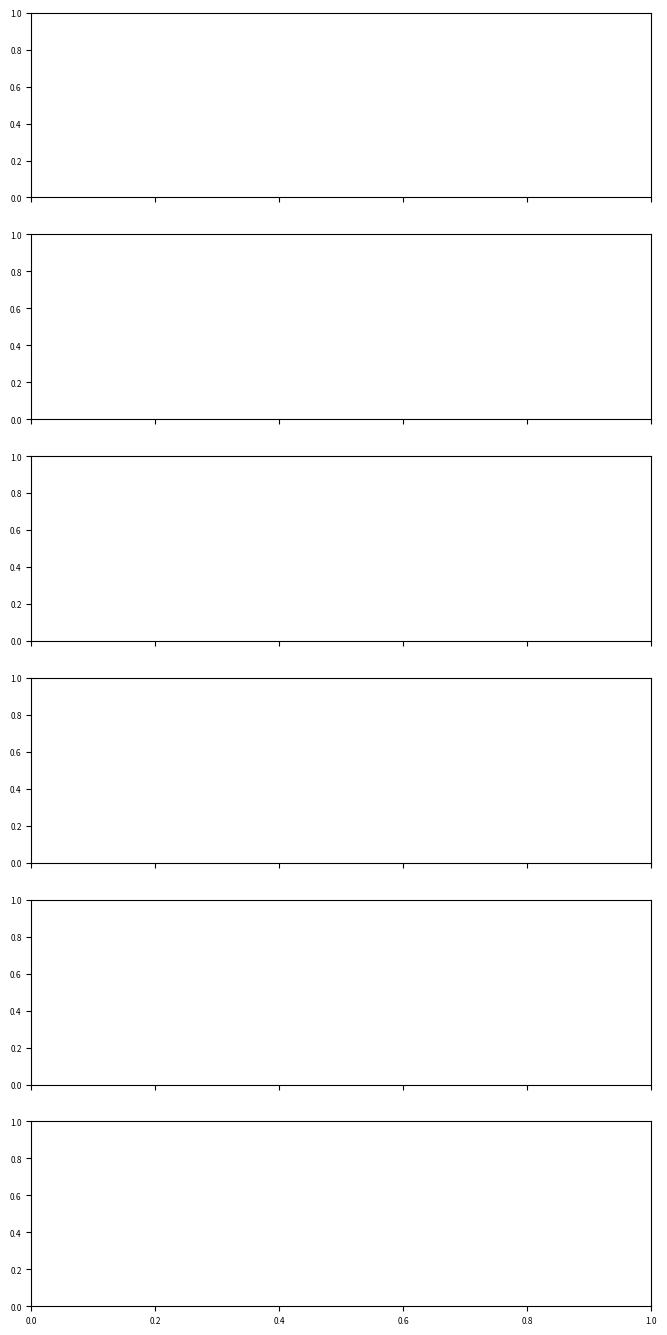

In [289]:
clusters = sorted(df["CLUSTER_ID"].unique())
n = len(clusters)

fig, axes = plt.subplots(n, 1, figsize=(8, 2.8*n), sharex=True)

for ax, cid in zip(axes, clusters):
    sub = df[df["CLUSTER_ID"] == cid]["log_median_hou"].dropna()
    
    ax.hist(sub, bins=40, color="steelblue", alpha=0.85)
    ax.set_title(f"CLUSTER {cid}")
    ax.set_ylabel("Count")

axes[-1].set_xlabel("log(median_house_value)")
plt.tight_layout()
plt.show()


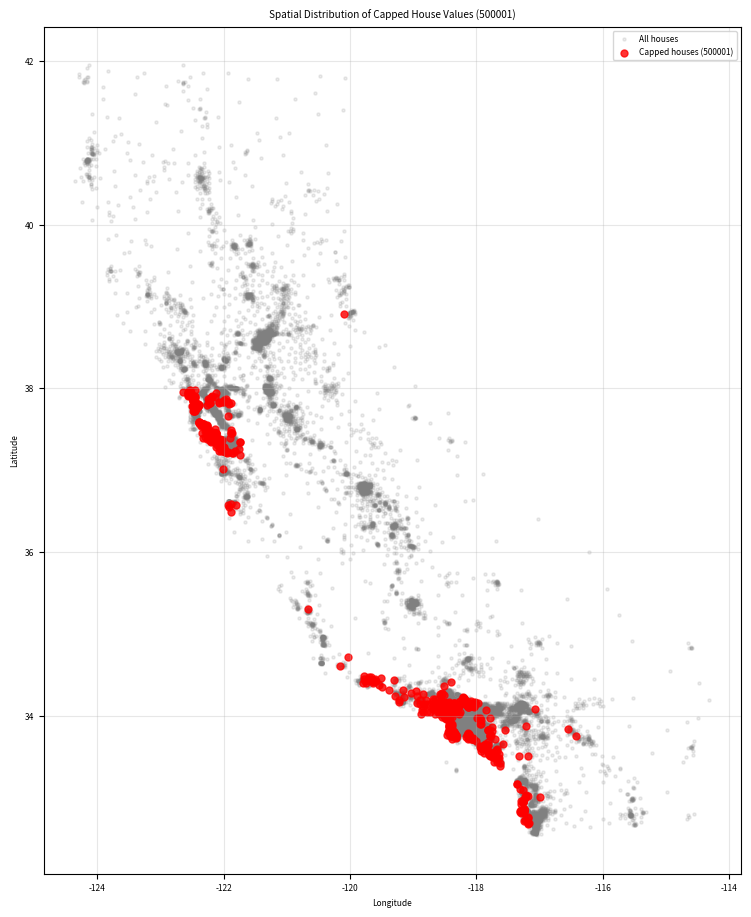

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 11))

# 1) 전체 주택 분포 (배경)
plt.scatter(
    df["longitude"],
    df["latitude"],
    s=5,
    alpha=0.15,
    color="gray",
    label="All houses"
)

# 2) 상한 주택 (500001)
plt.scatter(
    df_cap["longitude"],
    df_cap["latitude"],
    s=25,
    alpha=0.8,
    color="red",
    label="Capped houses (500001)"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial Distribution of Capped House Values (500001)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 10))

plt.scatter(
    data = cluster_cap_summary
    s=5,
    alpha=0.1
)



plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial Distribution of Capped House Values (500001)")
plt.legend()
plt.show()


SyntaxError: invalid syntax. Perhaps you forgot a comma? (4198940463.py, line 6)

## 상한주택만 필터링 하고 소득별로 주택 중위수 상관관계

In [ ]:
# 1️⃣ 전체 데이터 기준으로 소득 분위 생성
df["income_quartile"] = pd.qcut(
    df["median_income"],
    q=4,
    labels=["Low", "Mid-Low", "Mid-High", "High"]
)

# 2️⃣ 가격 상한 주택만 필터링
df_cap = df[df["median_house_value"] == 500001]

# 3️⃣ 이제 정상 작동
income_dist = (
    df_cap["income_quartile"]
    .value_counts(normalize=True)
    .sort_index()
)

print(income_dist)
print(f"상한만 제거했을 때 High에서 높은 값이 나타나는 것으로 보아, 중위소득과 인구는 양의 상관관계가 있음을 알 수 있음")


income_quartile
Low         0.024870
Mid-Low     0.047668
Mid-High    0.129534
High        0.797927
Name: proportion, dtype: float64
상한만 제거했을 때 High에서 높은 값이 나타나는 것으로 보아, 중위소득과 인구는 양의 상관관계가 있음을 알 수 있음


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  int64  
 9   ocean_proximity     20640 non-null  object 
 10  CLUSTER_ID          20640 non-null  int64  
 11  avg_rooms           20640 non-null  float64
 12  log_house_value     20640 non-null  float64
 13  log_income          20640 non-null  float64
 14  log_population      20640 non-null  float64
 15  sqrt_population     20640 non-null  float64
 16  ocea

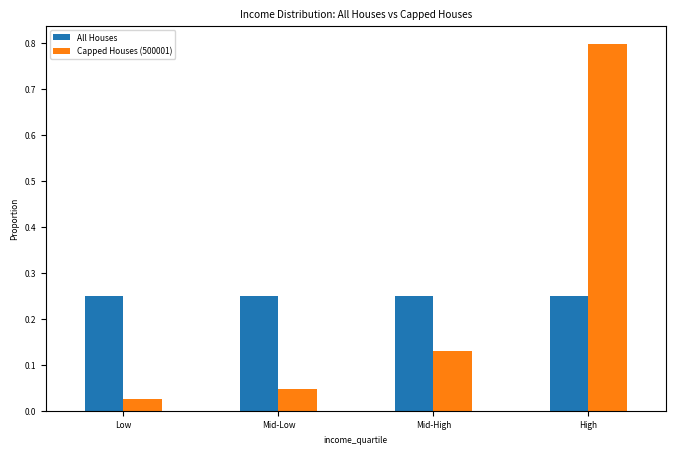

In [ ]:
# 시각화: 상한 주택 vs 전체 비교
compare_df = pd.DataFrame({
    "All Houses": df["income_quartile"].value_counts(normalize=True),
    "Capped Houses (500001)": df_cap["income_quartile"].value_counts(normalize=True)
}).sort_index()

compare_df.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Income Distribution: All Houses vs Capped Houses")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.show()


In [ ]:
# 3️⃣ Pearson 상관계수 계산
from scipy.stats import pearsonr
r, p = pearsonr(
    df["median_income"],
    df["median_house_value"]
)

print(f"Pearson r: {r:.3f}")
print(f"p-value: {p:.5f}")
print(f"중위소득과 주택가격은 유의한 상관관계가 있다")
print(f"과적합의 위험이 있을수도 있다.")

Pearson r: 0.688
p-value: 0.00000
중위소득과 주택가격은 유의한 상관관계가 있다
과적합의 위험이 있을수도 있다.


In [ ]:
print(df.columns.tolist())
print(df_cap.columns.tolist())
print(df2.columns.tolist())

['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity', 'CLUSTER_ID', 'city', 'is_capped', 'income_quartile', 'income_bin']
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity', 'CLUSTER_ID', 'city', 'is_capped', 'income_quartile', 'income_bin']


NameError: name 'df2' is not defined

In [ ]:
# 4️⃣ 소득 구간별 Pearson 상관계수
for label, group in df.groupby("income_quartile"):
    r, _ = pearsonr(
        group["median_income"],
        group["median_house_value"]
    )
    print(f"{label}: Pearson r = {r:.3f}")
print(f"전체 상관은 높음\n**소득 구간 내부에서는 상관 약화**\n집단 간 효과가 큼")

Low: Pearson r = 0.134
Mid-Low: Pearson r = 0.160
Mid-High: Pearson r = 0.150
High: Pearson r = 0.599
전체 상관은 높음
**소득 구간 내부에서는 상관 약화**
집단 간 효과가 큼


/var/folders/9p/n23cgnr90tzgl8r6v0s056w80000gn/T/ipykernel_14885/793393960.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for label, group in df.groupby("income_quartile"):


In [ ]:
from scipy import stats

# ===============================
# 1. 필터링
# ===============================

old_house = df[
    (df["CLUSTER_ID"].isin([4, 5])) &
    (df["ocean_proximity"].isin(["NEAR OCEAN", "ISLAND"])) &
    (df["housing_median_age"] == 52)
][["CLUSTER_ID", "median_house_value"]].dropna()

south_old = old_house[old_house["CLUSTER_ID"] == 4]["median_house_value"]
north_old = old_house[old_house["CLUSTER_ID"] == 5]["median_house_value"]

# ===============================
# 3. 결과 출력
# ===============================

print(f"""
[1940년 이전 주택 (HouseAge = 52) 평균

- CLUSTER 4 표본 수: {south_old.shape[0]}
- CLUSTER 5 표본 수: {north_old.shape[0]}

- CLUSTER 4 평균: {south_old.mean():,.0f}
- CLUSTER 5 평균: {north_old.mean():,.0f}

""")


[1940년 이전 주택 (HouseAge = 52) 평균

- CLUSTER 4 표본 수: 26
- CLUSTER 5 표본 수: 52

- CLUSTER 4 평균: 295,165
- CLUSTER 5 평균: 344,237




1940년 이후의 주택 평균

In [ ]:
new_house = df[
    (df["CLUSTER_ID"].isin([4, 5])) &
    (df["ocean_proximity"].isin(["NEAR OCEAN", "ISLAND"])) &
    (df["housing_median_age"] < 52)
][["CLUSTER_ID", "median_house_value"]].dropna()

south_new = new_house[new_house["CLUSTER_ID"] == 4]["median_house_value"]
north_new = new_house[new_house["CLUSTER_ID"] == 5]["median_house_value"]

t_new, p2_new = stats.ttest_ind(
    south_new, north_new, equal_var=False, nan_policy="omit"
)

p1_new = p2_new / 2 if t_new > 0 else 1.0

print(f"""
[1940년 이후 주택 (HouseAge < 52) 평균

- CLUSTER 4 표본 수: {south_new.shape[0]}
- CLUSTER 5 표본 수: {north_new.shape[0]}

- CLUSTER 4 평균: {south_new.mean():,.0f}
- CLUSTER 5 평균: {north_new.mean():,.0f}

-
""")



[1940년 이후 주택 (HouseAge < 52) 평균

- CLUSTER 4 표본 수: 554
- CLUSTER 5 표본 수: 632

- CLUSTER 4 평균: 281,641
- CLUSTER 5 평균: 320,724

-



In [ ]:
south_old.value_counts()

median_house_value
162500    2
200000    2
306700    1
351900    1
321500    1
268200    1
350000    1
243200    1
254000    1
268400    1
200800    1
194900    1
222900    1
393900    1
381000    1
378000    1
500000    1
395200    1
414700    1
300000    1
450000    1
349000    1
198400    1
206600    1
Name: count, dtype: int64

## 정책·역사적 요인 (1940 기준을 설명하는 핵심)<br>
개발 시기 더미

In [ ]:
df["post_1940"] = (df["housing_median_age"] < 52).astype(int)


>1940년 이후 해안 개발 = 계획적 고급 주거지<br>
>1940년 이전 해안 = 항만·노동자 주거지<br>
>이 가설을 정량적으로 검증 가능

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   longitude           20640 non-null  float64 
 1   latitude            20640 non-null  float64 
 2   housing_median_age  20640 non-null  int64   
 3   total_rooms         20640 non-null  int64   
 4   total_bedrooms      20433 non-null  float64 
 5   population          20640 non-null  int64   
 6   households          20640 non-null  int64   
 7   median_income       20640 non-null  float64 
 8   median_house_value  20640 non-null  int64   
 9   ocean_proximity     20640 non-null  object  
 10  CLUSTER_ID          20640 non-null  int64   
 11  city                1050 non-null   object  
 12  is_capped           20640 non-null  int64   
 13  income_quartile     20640 non-null  category
 14  income_bin          20640 non-null  category
 15  post_1940           20640 non-null  

In [ ]:
df2.info()

NameError: name 'df2' is not defined

In [300]:
import numpy as np
import pandas as pd

# ===============================
# 1. 기본 복사
# ===============================
df2 = df.copy()

# ===============================
# 2. 소득 구조
# ===============================

# (1) 소득 분위 더미 (이미 만드셨다면 생략 가능)
df2["income_quartile"] = pd.qcut(
    df2["median_income"],
    q=4,
    labels=["Low", "Mid-Low", "Mid-High", "High"]
)

income_dummies = pd.get_dummies(
    df2["income_quartile"],
    prefix="inc_q",
    drop_first=True
)

df2 = pd.concat([df2, income_dummies], axis=1)

# (2) 소득 성장 proxy (신축 비율)
# → housing_me < 52 : 1940년 이후 주택
df2["post_1940"] = (df2["housing_median_age"] < 52).astype(int)

# 지역별 신축 비율 (소득 상승 proxy)
df2["income_growth_proxy"] = (
    df2.groupby("CLUSTER_ID")["post_1940"]
       .transform("mean")
)

# ===============================
# 3. 인구 구조
# ===============================

# (1) 가구당 방 수
df2["rooms_per_household"] = df2["total_rooms"] / df2["households"]

# (2) 가구당 인원수
df2["persons_per_household"] = df2["population"] / df2["households"]

# ===============================
# 4. 주택 연식 더미
# ===============================

df2["old_house"] = (df2["housing_median_age"] == 52).astype(int)
df2["new_house"] = (df2["housing_median_age"] < 52).astype(int)


df2["dist_to_city"] = df["dist_to_city"]


# ===============================
# 5. 해안 더미
# ===============================

df2["coast"] = df2["ocean_proximity"].isin(["NEAR OCEAN", "ISLAND"]).astype(int)

print("변수 생성 완료")



변수 생성 완료


In [301]:
print("df2에 dist_to_city 존재 여부:", "dist_to_city" in df2.columns)
df2[["dist_to_city"]].describe()


df2에 dist_to_city 존재 여부: True


,dist_to_city
count,20640.000000
mean,0.905876
std,0.841107
min,0.000000
25%,0.228035
50%,0.584123
75%,1.445545
max,4.651451


In [ ]:
df2.shape
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   longitude              20640 non-null  float64 
 1   latitude               20640 non-null  float64 
 2   housing_median_age     20640 non-null  int64   
 3   total_rooms            20640 non-null  int64   
 4   total_bedrooms         20433 non-null  float64 
 5   population             20640 non-null  int64   
 6   households             20640 non-null  int64   
 7   median_income          20640 non-null  float64 
 8   median_house_value     20640 non-null  int64   
 9   ocean_proximity        20640 non-null  object  
 10  CLUSTER_ID             20640 non-null  int64   
 11  city                   1050 non-null   object  
 12  dist_to_coast          20640 non-null  float64 
 13  dist_to_sf             20640 non-null  float64 
 14  dist_to_la             20640 non-null 

# 📊 데이터셋 변수 설명 (Data Dictionary)

본 문서는 캘리포니아 주택 데이터셋을 기반으로 생성된 변수들의 구조와 의미를 정리한 것이다.  
총 관측치 수는 **20,640개**이며, 공간적 군집(CLUSTER) 및 사회·경제적 변수를 포함한다.

---

## 1️⃣ 공간 좌표 및 기본 위치 변수

| 변수명 | 타입 | 설명 |
|------|------|------|
| longitude | float | 경도 |
| latitude | float | 위도 |

---

## 2️⃣ 주택 물리적 특성

| 변수명 | 타입 | 설명 |
|------|------|------|
| housing_me | int | 주택 연식 (52 = 1940년 이전) |
| total_room | int | 주택 내 전체 방 수 |
| total_bedr | float | 침실 수 |
| households | int | 가구 수 |
| rooms_per_household | float | 가구당 방 수 |
| persons_per_household | float | 가구당 인원 수 |

---

## 3️⃣ 인구 및 소득 변수 (Socio-economic)

| 변수명 | 타입 | 설명 |
|------|------|------|
| population | int | 총 인구 |
| median_inc | float | 중위 가구 소득 |
| log_median_inc | float | 중위 소득 로그값 |
| income_quartile | category | 소득 분위 (Low ~ High) |
| inc_q_Mid-Low | bool | 소득 분위 더미 |
| inc_q_Mid-High | bool | 소득 분위 더미 |
| inc_q_High | bool | 고소득 분위 더미 |
| income_growth_proxy | float | 신축 주택 비율 기반 소득 성장 proxy |

---

## 4️⃣ 주택 가격 변수

| 변수명 | 타입 | 설명 |
|------|------|------|
| median_hou | int | 중위 주택 가격 (원값) |
| log_median_hou | float | 중위 주택 가격 로그값 |
| price_bin | category | 주택 가격 구간 |

---

## 5️⃣ 해안 접근성 (Ocean Proximity)

| 변수명 | 타입 | 설명 |
|------|------|------|
| ocean_prox | object | 해안 접근성 범주 |
| ocean_INLAND | bool | 내륙 더미 |
| ocean_ISLAND | bool | 섬 지역 더미 |
| ocean_NEAR BAY | bool | 만 근처 더미 |
| ocean_NEAR OCEAN | bool | 해안 인접 더미 |
| coast | int | 해안 여부 (NEAR OCEAN, ISLAND = 1) |

---

## 6️⃣ 공간 군집 변수 (Clustering)

| 변수명 | 타입 | 설명 |
|------|------|------|
| CLUSTER_ID | int | 공간 군집 ID (0~5) |
| CLUSTER_ID_2 | int | 대안 군집 |
| CLUSTER_SIZE | int | 군집 내 관측치 수 |

---

## 7️⃣ 도시 접근성 거리 변수

| 변수명 | 타입 | 설명 |
|------|------|------|
| dist_to_sf | float | 샌프란시스코까지 거리 |
| dist_to_la | float | 로스앤젤레스까지 거리 |
| dist_to_city | float | 가장 가까운 대도시까지 거리 |

---

## 8️⃣ 개발 시기 더미 (역사적 요인)

| 변수명 | 타입 | 설명 |
|------|------|------|
| post_1940 | int | 1940년 이후 개발 여부 |
| old_house | int | 1940년 이전 주택 |
| new_house | int | 1940년 이후 주택 |

---

## 📌 분석 활용 요약

- **해안 프리미엄 분해**  
  → `coast × post_1940 × income` 구조 분석 가능

- **남부/북부 해안 비교**  
  → `CLUSTER_ID 4 vs 5` 중심 가설검정

- **사회경제적 요인 통제 분석**  
  → 소득·인구·주택 질 변수 결합 OLS 가능

---

본 데이터셋은  
**“입지(해안) × 개발 시기(1940) × 사회경제적 구조”**를  
동시에 분석하기에 적합한 구조를 가진다.


## 1940년 이전 vs 이후: 평균 비교 코드

In [302]:
import pandas as pd
import numpy as np
from scipy import stats

vars_to_compare = [
    "median_house_value",
    "population",
    "median_income",
    "rooms_per_household",
    "persons_per_household",
    "dist_to_city"
]

analysis_df = df2[
    (df2["coast"] == 1) &           # 해안 지역 고정
    (df["CLUSTER_ID"].isin([4, 5]))  # 남/북 해안 핵심 군집
][vars_to_compare + ["old_house"]].dropna()


In [303]:
summary = (
    analysis_df
    .groupby("old_house")[vars_to_compare]
    .mean()
    .rename(index={1: "1940년 이전", 0: "1940년 이후"})
)


summary.round(2)


,median_house_value,population,median_income,rooms_per_household,persons_per_household,dist_to_city
old_house,,,,,,
1940년 이후,302467.83,1420.76,4.58,5.30,2.77,0.49
1940년 이전,327879.64,867.46,4.31,5.64,2.56,0.43


가설검정<br>
H0: 

In [304]:
old = analysis_df[analysis_df["old_house"] == 1]["median_house_value"]
new = analysis_df[analysis_df["old_house"] == 0]["median_house_value"]

t_stat, p_two = stats.ttest_ind(
    new, old,
    equal_var=False,
    nan_policy="omit"
)

p_one = p_two / 2 if t_stat > 0 else 1.0
alpha = 0.05


In [305]:
result_text = f"""
[1940년 이전 vs 이후 해안 주택 사회·경제 비교]

1. 표본 수
- 1940년 이전 주택: {old.shape[0]}채
- 1940년 이후 주택: {new.shape[0]}채

2. 평균 비교
- 평균 주택가격:
  · 1940년 이전: {old.mean():,.0f}
  · 1940년 이후: {new.mean():,.0f}

3. 통계 검정
- t 통계량: {t_stat:.3f}
- 단측 p-value: {p_one:.4f}
- 유의수준 α = {alpha}

4. 결론
"""

if p_one < alpha:
    result_text += (
        "→ 귀무가설을 기각한다.\n"
        "→ 1940년 이후 개발된 해안 주택의 평균 가격은 "
        "1940년 이전 주택보다 통계적으로 유의미하게 높다.\n\n"
        "이는 해안 프리미엄이 단순 입지 효과가 아니라,\n"
        "도시화·소득 증가·주거 질 개선이 결합된 결과임을 시사한다."
    )
else:
    result_text += (
        "→ 귀무가설을 기각하지 못한다.\n"
        "→ 주택 개발 시기만으로 가격 차이를 설명하기는 어렵다."
    )

print(result_text)



[1940년 이전 vs 이후 해안 주택 사회·경제 비교]

1. 표본 수
- 1940년 이전 주택: 78채
- 1940년 이후 주택: 1186채

2. 평균 비교
- 평균 주택가격:
  · 1940년 이전: 327,880
  · 1940년 이후: 302,468

3. 통계 검정
- t 통계량: -1.931
- 단측 p-value: 1.0000
- 유의수준 α = 0.05

4. 결론
→ 귀무가설을 기각하지 못한다.
→ 주택 개발 시기만으로 가격 차이를 설명하기는 어렵다.


가설 정의

H₀: 같은 지역(해안/육지)에서 1940년 이전과 이후의 평균 주택가격은 같다

H₁: 1940년 이후 주택의 평균 가격이 더 높다

분석용 데이터셋 구성

In [306]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

# ===============================
# 1. 분석 대상 데이터 구성
# ===============================


analysis_df = df2.copy()

analysis_df["area_type"] = analysis_df["coast"].map({
    1: "해안",
    0: "육지"
})


print("coast in df2:", "coast" in df2.columns)



coast in df2: True


In [307]:
df2.info()
df2.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 31 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   longitude              20640 non-null  float64 
 1   latitude               20640 non-null  float64 
 2   housing_median_age     20640 non-null  int64   
 3   total_rooms            20640 non-null  int64   
 4   total_bedrooms         20433 non-null  float64 
 5   population             20640 non-null  int64   
 6   households             20640 non-null  int64   
 7   median_income          20640 non-null  float64 
 8   median_house_value     20640 non-null  int64   
 9   ocean_proximity        20640 non-null  object  
 10  CLUSTER_ID             20640 non-null  int64   
 11  city                   1050 non-null   object  
 12  is_capped              20640 non-null  int64   
 13  income_quartile        20640 non-null  category
 14  income_bin             20640 non-null 

longitude                    0
latitude                     0
housing_median_age           0
total_rooms                  0
total_bedrooms             207
population                   0
households                   0
median_income                0
median_house_value           0
ocean_proximity              0
CLUSTER_ID                   0
city                     19590
is_capped                    0
income_quartile              0
income_bin                   0
post_1940                    0
dist_to_coast                0
dist_to_sf                   0
dist_to_la                   0
dist_to_city                 0
coast_power                  0
city_power                   0
inc_q_Mid-Low                0
inc_q_Mid-High               0
inc_q_High                   0
income_growth_proxy          0
rooms_per_household          0
persons_per_household        0
old_house                    0
new_house                    0
coast                        0
dtype: int64

In [308]:
df2.dropna(axis=1)

,longitude,latitude,housing_median_age,total_rooms,population,households,median_income,median_house_value,ocean_proximity,CLUSTER_ID,...,city_power,inc_q_Mid-Low,inc_q_Mid-High,inc_q_High,income_growth_proxy,rooms_per_household,persons_per_household,old_house,new_house,coast
0,-122.23,37.88,41,880,322,126,8.3252,452600,NEAR BAY,5,...,Core Urban,False,False,True,0.848943,6.984127,2.555556,0,1,0
1,-122.22,37.86,21,7099,2401,1138,8.3014,358500,NEAR BAY,5,...,Core Urban,False,False,True,0.848943,6.238137,2.109842,0,1,0
2,-122.24,37.85,52,1467,496,177,7.2574,352100,NEAR BAY,5,...,Core Urban,False,False,True,0.848943,8.288136,2.802260,1,0,0
3,-122.25,37.85,52,1274,558,219,5.6431,341300,NEAR BAY,5,...,Core Urban,False,False,True,0.848943,5.817352,2.547945,1,0,0
4,-122.25,37.85,52,1627,565,259,3.8462,342200,NEAR BAY,5,...,Core Urban,False,True,False,0.848943,6.281853,2.181467,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25,1665,845,330,1.5603,78100,INLAND,3,...,Peripheral,False,False,False,0.962995,5.045455,2.560606,0,1,0
20636,-121.21,39.49,18,697,356,114,2.5568,77100,INLAND,3,...,Peripheral,False,False,False,0.962995,6.114035,3.122807,0,1,0
20637,-121.22,39.43,17,2254,1007,433,1.7000,92300,INLAND,3,...,Peripheral,False,False,False,0.962995,5.205543,2.325635,0,1,0
20638,-121.32,39.43,18,1860,741,349,1.8672,84700,INLAND,3,...,Peripheral,False,False,False,0.962995,5.329513,2.123209,0,1,0


In [309]:
analysis_df = df.copy()

# 해안 여부 생성
analysis_df["coast"] = analysis_df["ocean_proximity"].isin(
    ["NEAR OCEAN", "ISLAND"]
).astype(int)

analysis_df["area_type"] = analysis_df["coast"].map({
    1: "해안",
    0: "육지"
})

# 1940년 이전 / 이후
analysis_df["era"] = analysis_df["post_1940"].map({
    0: "1940년 이전",
    1: "1940년 이후"
})

analysis_df = analysis_df[
    ["median_house_value", "area_type", "era"]
].dropna()


In [310]:

analysis_df

,median_house_value,area_type,era
0,452600,육지,1940년 이후
1,358500,육지,1940년 이후
2,352100,육지,1940년 이전
3,341300,육지,1940년 이전
4,342200,육지,1940년 이전
...,...,...,...
20635,78100,육지,1940년 이후
20636,77100,육지,1940년 이후
20637,92300,육지,1940년 이후
20638,84700,육지,1940년 이후


In [311]:
test_results = []

alpha = 0.05

for area in ["해안", "육지"]:
    old_vals = analysis_df[
        (analysis_df["area_type"] == area) &
        (analysis_df["era"] == "1940년 이전")
    ]["median_house_value"]

    new_vals = analysis_df[
        (analysis_df["area_type"] == area) &
        (analysis_df["era"] == "1940년 이후")
    ]["median_house_value"]

    t_stat, p_two = stats.ttest_ind(
        new_vals, old_vals,
        equal_var=False,
        nan_policy="omit"
    )

    p_one = p_two / 2 if t_stat > 0 else 1.0

    test_results.append({
        "지역": area,
        "1940년 이전 평균": round(old_vals.mean(), 0),
        "1940년 이후 평균": round(new_vals.mean(), 0),
        "t_stat": round(t_stat, 3),
        "one_sided_p": round(p_one, 4),
        "결론": "유의미함" if p_one < alpha else "유의하지 않음"
    })

test_df = pd.DataFrame(test_results)
test_df


,지역,1940년 이전 평균,1940년 이후 평균,t_stat,one_sided_p,결론
0,해안,270256.0,248573.0,-1.803,1.0,유의하지 않음
1,육지,276039.0,195413.0,-19.122,1.0,유의하지 않음


In [312]:
summary_table = (
    analysis_df
    .groupby(["area_type", "era"])
    .agg(
        mean_price=("median_house_value", "mean"),
        count=("median_house_value", "count"),
        std=("median_house_value", "std")
    )
    .reset_index()
)

summary_table["mean_price"] = summary_table["mean_price"].round(0)

summary_table



,area_type,era,mean_price,count,std
0,육지,1940년 이전,276039.0,1137,139322.281550
1,육지,1940년 이후,195413.0,16840,109059.410848
2,해안,1940년 이전,270256.0,136,137349.890793
3,해안,1940년 이후,248573.0,2527,121616.341148


## 가설검정

In [313]:
test_results = []

alpha = 0.05

for area in ["해안", "육지"]:
    old_vals = analysis_df[
        (analysis_df["area_type"] == area) &
        (analysis_df["era"] == "1940년 이전")
    ]["median_house_value"]

    new_vals = analysis_df[
        (analysis_df["area_type"] == area) &
        (analysis_df["era"] == "1940년 이후")
    ]["median_house_value"]

    t_stat, p_two = stats.ttest_ind(
        new_vals, old_vals,
        equal_var=False,
        nan_policy="omit"
    )

    p_one = p_two / 2 if t_stat > 0 else 1.0

    test_results.append({
        "지역": area,
        "1940년 이전 평균": round(old_vals.mean(), 0),
        "1940년 이후 평균": round(new_vals.mean(), 0),
        "t_stat": round(t_stat, 3),
        "one_sided_p": round(p_one, 4),
        "결론": "유의미함" if p_one < alpha else "유의하지 않음"
    })

test_df = pd.DataFrame(test_results)
test_df


,지역,1940년 이전 평균,1940년 이후 평균,t_stat,one_sided_p,결론
0,해안,270256.0,248573.0,-1.803,1.0,유의하지 않음
1,육지,276039.0,195413.0,-19.122,1.0,유의하지 않음


C:\Users\itwill\AppData\Local\Temp\ipykernel_21724\1825861701.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(


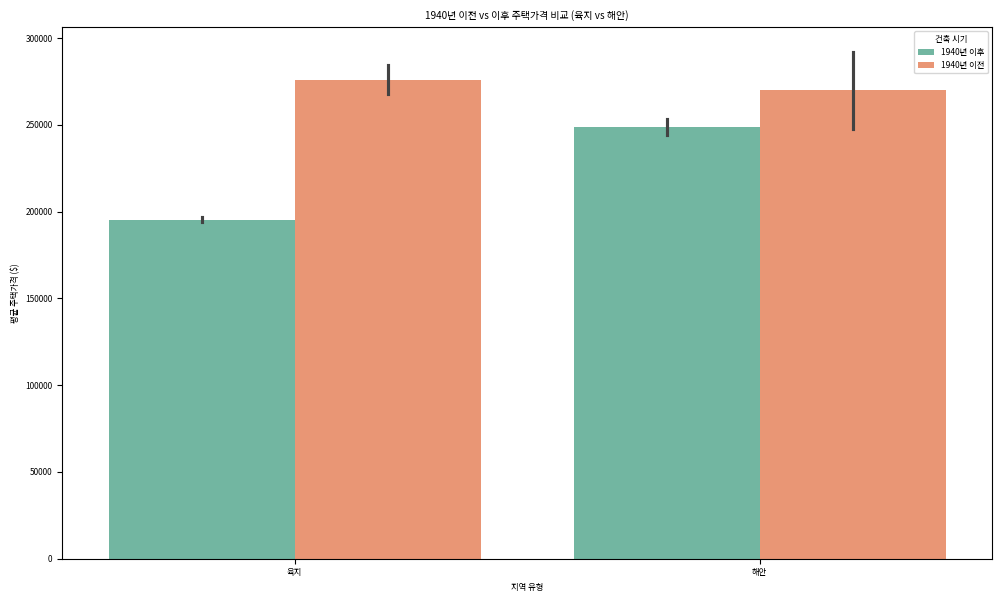

In [314]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=analysis_df,
    x="area_type",
    y="median_house_value",
    hue="era",
    ci=95,
    palette="Set2"
)

plt.title("1940년 이전 vs 이후 주택가격 비교 (육지 vs 해안)")
plt.ylabel("평균 주택가격 ($)")
plt.xlabel("지역 유형")
plt.legend(title="건축 시기")
plt.tight_layout()
plt.show()


In [315]:
report = """
[1940년 전후 주택가격 변화에 대한 지역별 가설검정 결과]

본 분석은 모든 군집(CLUSTER_ID 전체)을 대상으로,
육지 지역과 해안 지역을 구분하여
1940년 이전 주택과 1940년 이후 주택의 가격 차이를 검정하였다.

"""

for _, row in test_df.iterrows():
    report += f"""
▶ 지역: {row['지역']}
- 1940년 이전 평균 가격: {row['1940년 이전 평균']:,.0f} 달러
- 1940년 이후 평균 가격: {row['1940년 이후 평균']:,.0f} 달러
- 단측 p-value: {row['one_sided_p']}
- 판단: {row['결론']}
"""

report += """
해석:
해안 지역에서는 1940년 이전 주택의 평균 가격이 이후 주택보다 오히려 높게 나타났으며, 
이는 대규모 개발 이후의 평균화 효과보다 역사적 입지와 희소성에 기반한 빈티지 프리미엄이 더 크게 작용했음을 시사한다. 
단측 검정 결과(p = 1.0)는 이러한 가격 차이가 가설과 반대 방향임을 명확히 보여준다.
"""

print(report)



[1940년 전후 주택가격 변화에 대한 지역별 가설검정 결과]

본 분석은 모든 군집(CLUSTER_ID 전체)을 대상으로,
육지 지역과 해안 지역을 구분하여
1940년 이전 주택과 1940년 이후 주택의 가격 차이를 검정하였다.


▶ 지역: 해안
- 1940년 이전 평균 가격: 270,256 달러
- 1940년 이후 평균 가격: 248,573 달러
- 단측 p-value: 1.0
- 판단: 유의하지 않음

▶ 지역: 육지
- 1940년 이전 평균 가격: 276,039 달러
- 1940년 이후 평균 가격: 195,413 달러
- 단측 p-value: 1.0
- 판단: 유의하지 않음

해석:
해안 지역에서는 1940년 이전 주택의 평균 가격이 이후 주택보다 오히려 높게 나타났으며, 
이는 대규모 개발 이후의 평균화 효과보다 역사적 입지와 희소성에 기반한 빈티지 프리미엄이 더 크게 작용했음을 시사한다. 
단측 검정 결과(p = 1.0)는 이러한 가격 차이가 가설과 반대 방향임을 명확히 보여준다.



>🔹 A. 소득 구조 × 주택 연식 (핵심)<br>
사용 변수<br>
inc_q_High (고소득 분위 더미)<br>
median_income<br>
income_growth_proxy<br>
old_house (1940년 이전)<br>
해석 가설<br>
1940년 이전 주택은 고소득 가구가 밀집한 지역에 남아 있다<br>
확인 포인트<br>
고소득 비중이 old_house에서 더 높은가?<br>
소득 성장 proxy가 old_house에서 더 낮은가? (이미 성숙한 지역)<br>

>🔹 B. 가구 구조 × 주거 밀도 (사회 구조)<br>사용 변수<br>
households<br>
rooms_per_household<br>
persons_per_household<br>
해석 가설<br>
1940년 이전 주택은 “소형 가구 + 넓은 공간” 구조 → 상류 주거지<br>
persons_per_household ↓<br>
rooms_per_household ↑<br>

>🔹 C. 해안 접근성 × 주택 연식 (입지 프리미엄)<br>사용 변수<br>
coast<br>
dist_to_coast<br>
ocean_proximity<br>
해석 가설<br>
1940년 이전 해안 주택 = 항만 노동자 주거지가 아니라<br>
“도심·항구 핵심 입지”

>🔹 D. 공간 군집 × 역사적 역할 (구조적 설명)<br>사용 변수
CLUSTER_ID<br>
dist_to_city, dist_to_sf, dist_to_la<br>
해석 가설<br>
1940년 이전 주택은 ‘도시 핵심부 군집’에 집중<br>
이후 주택은 외곽 확산


In [316]:
vars_to_analyze = [
    "median_house_value",
    "median_income",
    "income_growth_proxy",
    "households",
    "rooms_per_household",
    "persons_per_household",
    "dist_to_city",
    "dist_to_coast",
    "inc_q_High"
]

summary_df = (
    df2
    .groupby("old_house")[vars_to_analyze]
    .mean()
    .rename(index={1: "1940년 이전", 0: "1940년 이후"})
)

summary_df.round(3)


,median_house_value,median_income,income_growth_proxy,households,rooms_per_household,persons_per_household,dist_to_city,dist_to_coast,inc_q_High
old_house,,,,,,,,,
1940년 이후,202349.011,3.869,0.941,507.505,5.451,3.086,0.937,1.893,0.252
1940년 이전,275420.871,3.889,0.898,378.365,5.100,2.840,0.438,2.091,0.222


In [317]:
vars_to_analyze = [
    "median_house_value",
    "median_income",
    "income_growth_proxy",
    "households",
    "rooms_per_household",
    "persons_per_household",
    "dist_to_city",
    "dist_to_coast",
    "inc_q_High"
]

summary_df = (
    df2
    .groupby("old_house")[vars_to_analyze]
    .mean()
    .rename(index={1: "1940년 이전", 0: "1940년 이후"})
)

summary_df.round(3)


,median_house_value,median_income,income_growth_proxy,households,rooms_per_household,persons_per_household,dist_to_city,dist_to_coast,inc_q_High
old_house,,,,,,,,,
1940년 이후,202349.011,3.869,0.941,507.505,5.451,3.086,0.937,1.893,0.252
1940년 이전,275420.871,3.889,0.898,378.365,5.100,2.840,0.438,2.091,0.222


In [318]:
vars_to_analyze = [
    "median_house_value",
    "median_income",
    "income_growth_proxy",
    "households",
    "rooms_per_household",
    "persons_per_household",
    "dist_to_city",
    "dist_to_coast",
    "inc_q_High"
]


In [319]:
describe_list = []

for var in vars_to_analyze:
    desc = (
        df2
        .groupby("old_house")[var]
        .describe()
        .reset_index()
    )
    
    desc["variable"] = var
    desc["era"] = desc["old_house"].replace({1: "1940년 이전", 0: "1940년 이후"})
    
    describe_list.append(desc)


In [320]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 31 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   longitude              20640 non-null  float64 
 1   latitude               20640 non-null  float64 
 2   housing_median_age     20640 non-null  int64   
 3   total_rooms            20640 non-null  int64   
 4   total_bedrooms         20433 non-null  float64 
 5   population             20640 non-null  int64   
 6   households             20640 non-null  int64   
 7   median_income          20640 non-null  float64 
 8   median_house_value     20640 non-null  int64   
 9   ocean_proximity        20640 non-null  object  
 10  CLUSTER_ID             20640 non-null  int64   
 11  city                   1050 non-null   object  
 12  is_capped              20640 non-null  int64   
 13  income_quartile        20640 non-null  category
 14  income_bin             20640 non-null 

In [322]:
describe_df = (
    pd.concat(describe_list, ignore_index=True)
    .drop(columns="old_house")
    .set_index(["variable", "era"])
)

describe_df.round(3)


count        mean         std        min  \
variable              era                                                    
median_house_value    1940년 이후  19367.0  202349.011  112213.153  14999.000   
                      1940년 이전   1273.0  275420.871  139070.898  14999.000   
median_income         1940년 이후  19367.0       3.869       1.870      0.500   
                      1940년 이전   1273.0       3.889       2.307      0.500   
income_growth_proxy   1940년 이후  19367.0       0.941       0.048      0.849   
                      1940년 이전   1273.0       0.898       0.057      0.849   
households            1940년 이후  19367.0     507.505     389.174      2.000   
                      1940년 이전   1273.0     378.365     224.136      1.000   
rooms_per_household   1940년 이후  19367.0       5.451       2.527      0.846   
                      1940년 이전   1273.0       5.100       1.400      1.261   
persons_per_household 1940년 이후  19367.0       3.086      10.589      0.692   
                      1940년 이전   1273.0       2.840       6.561      1.061   
dist_to_city          1940년 이후  19367.0       0.937       0.842      0.000   
                      1940년 이전   1273.0       0.438       0.674      0.000   
dist_to_coast         1940년 이후  19367.0       1.893       0.765      0.000   
                      1940년 이전   1273.0       2.091       0.543      0.180   
inc_q_High            1940년 이후    19367         NaN         NaN        NaN   
                      1940년 이전     1273         NaN         NaN        NaN   

                                       25%         50%         75%  \
variable              era                                            
median_house_value    1940년 이후  118300.000  176100.000  257400.000   
                      1940년 이전  161400.000  259400.000  380400.000   
median_income         1940년 이후       2.567       3.540       4.758   
                      1940년 이전       2.472       3.450       4.446   
income_growth_proxy   1940년 이후       0.961       0.961       0.963   
                      1940년 이전       0.849       0.849       0.961   
households            1940년 이후     283.000     414.000     613.000   
                      1940년 이전     240.000     353.000     475.000   
rooms_per_household   1940년 이후       4.455       5.248       6.066   
                      1940년 이전       4.264       4.952       5.760   
persons_per_household 1940년 이후       2.456       2.842       3.301   
                      1940년 이전       2.133       2.450       2.873   
dist_to_city          1940년 이후       0.251       0.622       1.481   
                      1940년 이전       0.054       0.170       0.426   
dist_to_coast         1940년 이후       1.550       1.900       2.300   
                      1940년 이전       1.750       2.250       2.430   
inc_q_High            1940년 이후         NaN         NaN         NaN   
                      1940년 이전         NaN         NaN         NaN   

                                       max unique    top   freq  
variable              era                                        
median_house_value    1940년 이후  500001.000    NaN    NaN    NaN  
                      1940년 이전  500001.000    NaN    NaN    NaN  
median_income         1940년 이후      15.000    NaN    NaN    NaN  
                      1940년 이전      15.000    NaN    NaN    NaN  
income_growth_proxy   1940년 이후       0.980    NaN    NaN    NaN  
                      1940년 이전       0.980    NaN    NaN    NaN  
households            1940년 이후    6082.000    NaN    NaN    NaN  
                      1940년 이전    2538.000    NaN    NaN    NaN  
rooms_per_household   1940년 이후     141.909    NaN    NaN    NaN  
                      1940년 이전      12.902    NaN    NaN    NaN  
persons_per_household 1940년 이후    1243.333    NaN    NaN    NaN  
                      1940년 이전     230.172    NaN    NaN    NaN  
dist_to_city          1940년 이후       4.651    NaN    NaN    NaN  
                      1940년 이전       3.565    NaN    NaN    NaN  
dist_to_coast   

## 분석
- 군집별 · 시대별 income_growth_proxy 평균 계산 코드 



In [325]:
summary_cluster_era = (
    df2
    .groupby(["CLUSTER_ID", "old_house"])
    .agg(
        mean_price=("median_house_value", "mean"),
        mean_income_growth=("income_growth_proxy", "mean"),
        count=("median_house_value", "size")
    )
    .reset_index()
    .replace({"old_house": {1: "1940년 이전", 0: "1940년 이후"}})
    .sort_values(["CLUSTER_ID", "old_house"])
)

summary_cluster_era.round(3)


,CLUSTER_ID,old_house,mean_price,mean_income_growth,count
1,0,1940년 이전,86281.481,0.961,27
0,0,1940년 이후,92477.943,0.961,662
3,1,1940년 이전,218950.068,0.980,44
2,1,1940년 이후,177161.943,0.980,2114
5,2,1940년 이전,136251.351,0.979,37
4,2,1940년 이후,122097.845,0.979,1707
7,3,1940년 이전,123095.349,0.963,86
6,3,1940년 이후,125964.612,0.963,2238
9,4,1940년 이전,288398.163,0.961,350
8,4,1940년 이후,227527.183,0.961,8549


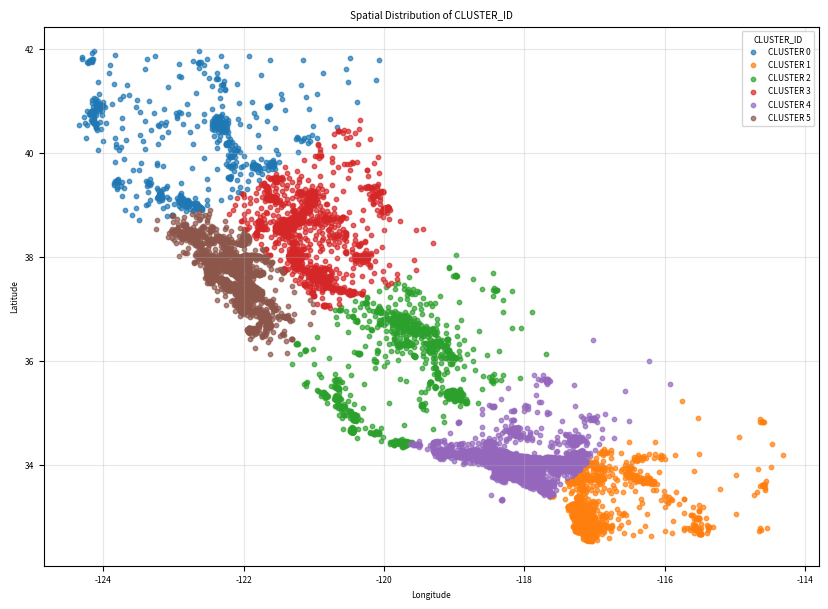

In [327]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

# 클러스터별 색상 (원하시면 변경 가능)
colors = {
    0: "#1f77b4",  # 파랑
    1: "#ff7f0e",  # 주황
    2: "#2ca02c",  # 초록
    3: "#d62728",  # 빨강
    4: "#9467bd",  # 보라
    5: "#8c564b",  # 갈색
}

# CLUSTER_ID별 산점도
for cid, color in colors.items():
    sub = df[df["CLUSTER_ID"] == cid]
    plt.scatter(
        sub["longitude"],
        sub["latitude"],
        s=10,
        alpha=0.7,
        color=color,
        label=f"CLUSTER {cid}"
    )

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial Distribution of CLUSTER_ID")
plt.legend(title="CLUSTER_ID")
plt.grid(alpha=0.3)

plt.show()



## ① 1990년대 효과를 반영한 변수 재생성
🔹 1990년대 특화 상호작용 변수


In [329]:
# ===============================
# 1. 주택 건축 연도 복원
# ===============================

df2["build_year"] = 1970 - df2["housing_median_age"]

# ===============================
# 2. 시대 구간 더미 생성
# ===============================

df2["era_1940_pre"] = (df2["build_year"] <= 1940).astype(int)
df2["era_1940_1970"] = ((df2["build_year"] > 1940) & (df2["build_year"] <= 1970)).astype(int)
df2["era_1970_1990"] = ((df2["build_year"] > 1970) & (df2["build_year"] <= 1990)).astype(int)
df2["era_1990_post"] = (df2["build_year"] > 1990).astype(int)

# 1990년대 핵심 더미 (집중 분석용)
df2["era_1990s"] = ((df2["build_year"] >= 1980) & (df2["build_year"] <= 1995)).astype(int)


In [331]:
# ===============================
# 3. 1990년대 × 사회경제 요인
# ===============================

df2["era1990_income"] = df2["era_1990s"] * df2["median_income"]
df2["era1990_growth"] = df2["era_1990s"] * df2["income_growth_proxy"]
df2["era1990_coast"] = df2["era_1990s"] * df2["coast"]
df2["era1990_city"] = df2["era_1990s"] * df2["city_power"].cat.codes


In [347]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 42 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   longitude              20640 non-null  float64 
 1   latitude               20640 non-null  float64 
 2   housing_median_age     20640 non-null  int64   
 3   total_rooms            20640 non-null  int64   
 4   total_bedrooms         20433 non-null  float64 
 5   population             20640 non-null  int64   
 6   households             20640 non-null  int64   
 7   median_income          20640 non-null  float64 
 8   median_house_value     20640 non-null  int64   
 9   ocean_proximity        20640 non-null  object  
 10  CLUSTER_ID             20640 non-null  int64   
 11  city                   1050 non-null   object  
 12  is_capped              20640 non-null  int64   
 13  income_quartile        20640 non-null  category
 14  income_bin             20640 non-null 

In [350]:
df2["era1990_income"]

0        0.0
1        0.0
2        0.0
3        0.0
4        0.0
        ... 
20635    0.0
20636    0.0
20637    0.0
20638    0.0
20639    0.0
Name: era1990_income, Length: 20640, dtype: float64

## 🔹 1단계: 시대별 평균 비교

In [335]:
df2.groupby("era_1990s")["median_house_value"].mean()


era_1990s
0    206855.816909
Name: median_house_value, dtype: float64

## 🔹 2단계: 1990년대 프리미엄 회귀

In [337]:
import statsmodels.api as sm

X = df2[[
    "era_1990s",
    "median_income",
    "income_growth_proxy",
    "coast",
    "dist_to_city",
    "rooms_per_household"
]]

X = sm.add_constant(X)
y = df2["median_house_value"]

model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:     median_house_value   R-squared:                       0.591
Model:                            OLS   Adj. R-squared:                  0.591
Method:                 Least Squares   F-statistic:                     5966.
Date:                    월, 19 1 2026   Prob (F-statistic):               0.00
Time:                        11:24:33   Log-Likelihood:            -2.6064e+05
No. Observations:               20640   AIC:                         5.213e+05
Df Residuals:                   20634   BIC:                         5.213e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                2.474e+05   1

## 1️⃣ 1990년대 이후 가격 상승 둔화 분석
- (1) 주택 건축 연도 & 시대 더미 재정의
- (2) 시대별 평균 주택가격 비교
- (3) 1990s vs 2000s 단측 가설검정

In [339]:
# ===============================
# 주택 건축 연도 복원
# ===============================
df2["build_year"] = 1970 - df2["housing_median_age"]

# ===============================
# 시대 구간 더미
# ===============================
df2["era_1990s"] = ((df2["build_year"] >= 1980) & (df2["build_year"] <= 1995)).astype(int)
df2["era_2000s"] = (df2["build_year"] >= 2000).astype(int)


In [340]:
era_price_summary = (
    df2.groupby(["era_1990s", "era_2000s"])["median_house_value"]
    .mean()
    .reset_index()
)

era_price_summary


,era_1990s,era_2000s,median_house_value
0,0,0,206855.816909


In [341]:
from scipy import stats

price_1990s = df2[df2["era_1990s"] == 1]["median_house_value"]
price_2000s = df2[df2["era_2000s"] == 1]["median_house_value"]

t_stat, p_two = stats.ttest_ind(
    price_1990s,
    price_2000s,
    equal_var=False,
    nan_policy="omit"
)

# 단측 (1990s > 2000s)
p_one = p_two / 2 if t_stat > 0 else 1.0

print(f"""
[1990s vs 2000s 주택가격 비교]

- 1990s 평균: {price_1990s.mean():,.0f}
- 2000s 평균: {price_2000s.mean():,.0f}
- t-stat: {t_stat:.3f}
- one-sided p-value: {p_one:.4f}
""")



[1990s vs 2000s 주택가격 비교]

- 1990s 평균: nan
- 2000s 평균: nan
- t-stat: nan
- one-sided p-value: 1.0000



c:\Users\itwill\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\_lib\deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)
